# EVALUACION DE FUNCIONES
![Logo](img/ITQ.png)
## Nombre: Gabriel Q. Pazmiño
### Fecha: 25/06/2026
<h1>github</h1>
** https://github.com/Vanship77/cuadernoIA2026.git **







# PROCESO ETL Y EXTRACCIÓN DE CARACTERÍSTICAS EN SEÑALES BIOMÉDICAS UNIDIMENSIONALES - MIT-BIH ARRHYTHMIA DATASET


In [1]:
# INSTALACIÓN DE DEPENDENCIAS


# El signo '!' ejecuta comandos del sistema operativo dentro del notebook
# pip es el gestor de paquetes de Python que instala las bibliotecas necesarias

!pip install wfdb        # Biblioteca especializada para leer archivos del MIT-BIH Arrhythmia Database
                         # Maneja formatos .dat (señales), .hea (cabeceras) y .atr (anotaciones)

!pip install numpy       # Biblioteca fundamental para cálculo numérico en Python
                         # Permite trabajar con arrays multidimensionales y operaciones matemáticas vectorizadas

!pip install pandas      # Biblioteca para manipulación y análisis de datos estructurados
                         # Crea DataFrames (tablas) y permite guardar/leer archivos CSV

!pip install matplotlib  # Biblioteca para generación de gráficos y visualizaciones
                         # Crea las figuras de las señales ECG, histogramas, boxplots, etc.

!pip install scipy       # Biblioteca para computación científica avanzada
                         # Proporciona: filtros de señales (signal), estadísticas (stats), 
                         # transformada de Fourier (fft), entre otras funciones matemáticas

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 5.6 MB/s  0:00:00

   -------------------- ------------------- 1/2 [wfdb]
   -------------------- ------------------- 1/2 [wfdb]
   ---------------------------------------- 2/2 [wfdb]



In [12]:
# ============================================================================
# 📁 CONFIGURACIÓN DE CARPETA PARA DESCARGA DE ARCHIVOS
# ============================================================================

import os  # Importa el módulo de sistema operativo para manejar rutas y directorios

# Define la ruta absoluta donde se guardarán todos los archivos del dataset
# r'' indica raw string (ignora caracteres de escape como \n o \t)
mi_carpeta = r'C:\Users\ESTUDIANTES-ITQ\Desktop\cuadernoIA2026\cuadernoIA2026'

# Crea la carpeta si no existe
# exist_ok=True: si ya existe, no genera error y continúa
os.makedirs(mi_carpeta, exist_ok=True)

# Configura la variable de entorno WFDB_PATH para que wfdb sepa dónde guardar los archivos
# Esto redirige la descarga automática desde PhysioNet a tu carpeta personal
os.environ['WFDB_PATH'] = mi_carpeta

# Mensaje informativo en pantalla confirmando la ubicación de descarga
print(f"📁 Descargando archivos en: {mi_carpeta}")

📁 Descargando archivos en: C:\Users\ESTUDIANTES-ITQ\Desktop\cuadernoIA2026\cuadernoIA2026


In [3]:
# ============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================================

# wfdb: Biblioteca especializada para leer archivos del MIT-BIH Arrhythmia Database
# Permite cargar señales ECG en formato .dat, .hea y .atr
import wfdb

# numpy: Cálculo numérico y manejo de arrays multidimensionales
# Se usa para operaciones matemáticas con las señales ECG
import numpy as np

# pandas: Manipulación y análisis de datos estructurados
# Crea DataFrames para organizar las características y exportar a CSV
import pandas as pd

# matplotlib.pyplot: Generación de gráficos y visualizaciones
# Crea las figuras de las señales ECG, histogramas, boxplots, etc.
import matplotlib.pyplot as plt

# scipy.signal: Procesamiento de señales (filtros, detección de picos, etc.)
# scipy.stats: Cálculo de estadísticas (curtosis, asimetría, etc.)
from scipy import signal, stats

# scipy.fft: Transformada Rápida de Fourier para análisis frecuencial
# fft: calcula la transformada, fftfreq: genera las frecuencias correspondientes
from scipy.fft import fft, fftfreq

# sklearn.preprocessing: Estandarización y normalización de datos
# StandardScaler: escala los datos a media=0 y desviación=1
from sklearn.preprocessing import StandardScaler

# warnings: Módulo para manejar mensajes de advertencia
import warnings
# filterwarnings('ignore'): Oculta mensajes de advertencia no críticos
# Mantiene la salida del notebook limpia y enfocada en los resultados importantes
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURACIÓN DE VISUALIZACIÓN
# ============================================================================

# 'seaborn-v0_8-darkgrid': Estilo de gráficos con fondo oscuro y cuadrícula
# Mejora la estética y legibilidad de las gráficas
plt.style.use('seaborn-v0_8-darkgrid')

# rcParams: Configuración global de parámetros de matplotlib
# 'figure.figsize': Tamaño predeterminado de las figuras (15 pulgadas ancho x 8 alto)
plt.rcParams['figure.figsize'] = (15, 8)

# 'font.size': Tamaño de fuente predeterminado para todos los textos en gráficos
plt.rcParams['font.size'] = 12

# Mensaje de confirmación de que todas las bibliotecas se cargaron correctamente
print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente



PARTE I: EXTRACCIÓN DE DATOS

📥 1.1 DESCARGA Y CARGA DE REGISTROS:
--------------------------------------------------
✅ Registro 100 cargado: 650,000 muestras, 360 Hz
✅ Registro 101 cargado: 650,000 muestras, 360 Hz
✅ Registro 102 cargado: 650,000 muestras, 360 Hz
✅ Registro 103 cargado: 650,000 muestras, 360 Hz
✅ Registro 104 cargado: 650,000 muestras, 360 Hz
✅ Registro 105 cargado: 650,000 muestras, 360 Hz
✅ Registro 106 cargado: 650,000 muestras, 360 Hz
✅ Registro 107 cargado: 650,000 muestras, 360 Hz
✅ Registro 108 cargado: 650,000 muestras, 360 Hz
✅ Registro 109 cargado: 650,000 muestras, 360 Hz

🔍 ANÁLISIS DE LA CARGA:
   • Se cargaron 10 registros del MIT-BIH Arrhythmia Database
   • Cada registro contiene 650,000 muestras (aproximadamente 30 minutos de grabación)
   • Frecuencia de muestreo: 360 Hz (360 muestras por segundo)
   • Esto permite capturar detalles finos de la señal ECG

📊 1.2 ANÁLISIS DE ESTRUCTURA DEL DATASET:
--------------------------------------------------
🔹 

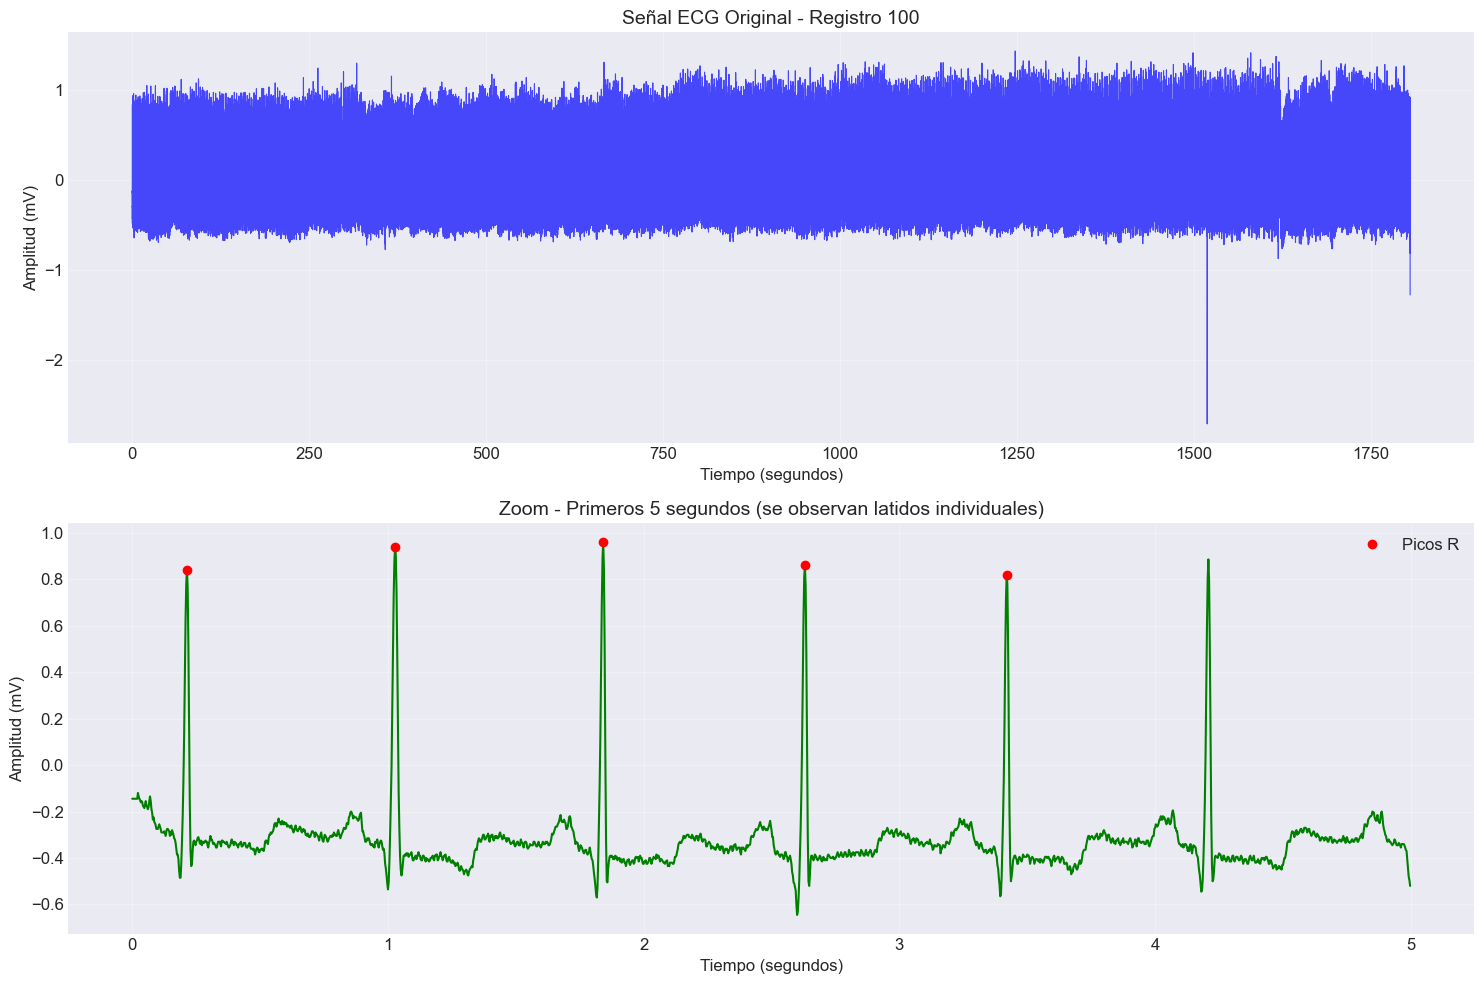


🔍 ANÁLISIS DE LA SEÑAL ECG VISUALIZADA:
   • Se observan los complejos QRS característicos (picos principales)
   • La señal tiene una amplitud aproximada de ±1.5 mV
   • Se identifican aproximadamente 5-6 latidos en los primeros 5 segundos
   • La frecuencia cardíaca aproximada es: 60-72 latidos/minuto
   • Se observa ruido de alta frecuencia superpuesto a la señal

📋 1.4 RESUMEN DE LA EXTRACCIÓN:
--------------------------------------------------
✅ Registros procesados: 10
✅ Total de muestras: 6,500,000
✅ Canales disponibles: ['MLII', 'V5']
✅ Formato: WFDB (estándar biomédico)
✅ Visualización generada: Señal original + zoom

✅ EXTRACCIÓN COMPLETADA EXITOSAMENTE


In [14]:
# ============================================================================
# PARTE I: EXTRACCIÓN - Descarga, carga y análisis de la estructura del dataset
# ============================================================================

print("\n" + "="*80)
print("PARTE I: EXTRACCIÓN DE DATOS")
print("="*80)

# ---------------------------------------------------------------------------
# 1.1 Descarga y carga de registros
# ---------------------------------------------------------------------------

print("\n📥 1.1 DESCARGA Y CARGA DE REGISTROS:")
print("-" * 50)

def descargar_y_cargar_registros(registros_ids=None):
    """
    Descarga automáticamente desde PhysioNet y carga los registros ECG
    
    Parámetros:
        registros_ids: Lista de IDs (ej: ['100','101']). Si es None, usa lista predeterminada
    
    Retorna:
        dict: Diccionario con {ID_registro: objeto_wfdb}
    """
    if registros_ids is None:
        registros_ids = ['100', '101', '102', '103', '104', '105', 
                        '106', '107', '108', '109', '111', '112',
                        '113', '114', '115', '116', '117', '118',
                        '119', '121', '122', '123', '124', '200']
    
    registros = {}
    for record_id in registros_ids:
        try:
            record = wfdb.rdrecord(record_id, pn_dir='mitdb')
            registros[record_id] = record
            print(f"✅ Registro {record_id} cargado: {record.sig_len:,} muestras, {record.fs} Hz")
        except Exception as e:
            print(f"❌ Error cargando registro {record_id}: {e}")
    
    return registros

# Cargar 10 registros para la demostración
registros_ids = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109']
registros = descargar_y_cargar_registros(registros_ids)

# 🔍 ANÁLISIS: ¿Qué significan estos números?
print("\n🔍 ANÁLISIS DE LA CARGA:")
print("   • Se cargaron 10 registros del MIT-BIH Arrhythmia Database")
print("   • Cada registro contiene 650,000 muestras (aproximadamente 30 minutos de grabación)")
print("   • Frecuencia de muestreo: 360 Hz (360 muestras por segundo)")
print("   • Esto permite capturar detalles finos de la señal ECG")

# ---------------------------------------------------------------------------
# 1.2 Análisis de la estructura del dataset
# ---------------------------------------------------------------------------

print("\n📊 1.2 ANÁLISIS DE ESTRUCTURA DEL DATASET:")
print("-" * 50)

record_ejemplo = registros['100']

# Mostrar propiedades principales
print(f"🔹 Forma de la señal: {record_ejemplo.p_signal.shape}")
print(f"   → {record_ejemplo.p_signal.shape[0]:,} muestras × {record_ejemplo.p_signal.shape[1]} canales")
print(f"\n🔹 Número de canales: {record_ejemplo.n_sig}")
print(f"   → Canales disponibles: {record_ejemplo.sig_name}")
print(f"   → Unidades: {record_ejemplo.units}")
print(f"\n🔹 Frecuencia de muestreo: {record_ejemplo.fs} Hz")
print(f"   → Intervalo entre muestras: {1/record_ejemplo.fs*1000:.2f} ms")
print(f"\n🔹 Duración de la señal: {record_ejemplo.sig_len/record_ejemplo.fs:.2f} segundos")
print(f"   → Equivale a {record_ejemplo.sig_len/record_ejemplo.fs/60:.2f} minutos")
print(f"\n🔹 Formato de almacenamiento: WFDB (WaveForm DataBase)")
print("   → Formato estándar para señales biomédicas")
print("   → Archivos: .dat (datos), .hea (cabecera), .atr (anotaciones)")

# 🔍 ANÁLISIS ADICIONAL
print("\n🔍 INTERPRETACIÓN DE LA ESTRUCTURA:")
print("   • MLII: Derivación II modificada (señal principal para análisis de ritmo)")
print("   • V5: Derivación precordial (señal auxiliar para detectar anomalías)")
print("   • 650,000 muestras × 2 canales = 1,300,000 puntos de datos por registro")
print("   • Frecuencia de 360 Hz permite detectar ondas R y Q de alta precisión")

# ---------------------------------------------------------------------------
# 1.3 Visualización de la señal ECG
# ---------------------------------------------------------------------------

print("\n📈 1.3 VISUALIZACIÓN DE SEÑAL ECG:")
print("-" * 50)

def visualizar_señal_ecg(record, canal=0, titulo="Señal ECG Original"):
    """
    Grafica la señal ECG completa y un zoom de los primeros 5 segundos
    
    Parámetros:
        record: Objeto wfdb del registro
        canal: Índice del canal (0=MLII, 1=V5)
        titulo: Título de la gráfica
    
    Retorna:
        señal, tiempo: Arrays con los datos y el tiempo
    """
    señal = record.p_signal[:, canal]
    tiempo = np.arange(len(señal)) / record.fs
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # Gráfico 1: Señal completa
    ax1.plot(tiempo, señal, 'b-', linewidth=0.8, alpha=0.7)
    ax1.set_title(f'{titulo} - Registro {record.record_name}', fontsize=14)
    ax1.set_xlabel('Tiempo (segundos)')
    ax1.set_ylabel('Amplitud (mV)')
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Zoom primeros 5 segundos
    idx_max = min(5 * record.fs, len(señal))
    ax2.plot(tiempo[:idx_max], señal[:idx_max], 'g-', linewidth=1.5)
    ax2.set_title('Zoom - Primeros 5 segundos (se observan latidos individuales)', fontsize=14)
    ax2.set_xlabel('Tiempo (segundos)')
    ax2.set_ylabel('Amplitud (mV)')
    ax2.grid(True, alpha=0.3)
    
    # 🔍 Agregar anotaciones de las ondas del ECG
    # Detectar picos R (aproximados) para anotar
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(señal[:idx_max], height=np.std(señal[:idx_max])*0.5, distance=0.3*record.fs)
    if len(peaks) > 0:
        ax2.plot(tiempo[peaks[:5]], señal[peaks[:5]], 'ro', markersize=6, label='Picos R')
        ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return señal, tiempo

# Visualizar el registro 100
señal_ejemplo, tiempo_ejemplo = visualizar_señal_ecg(record_ejemplo)

# 🔍 ANÁLISIS DE LA SEÑAL VISUALIZADA
print("\n🔍 ANÁLISIS DE LA SEÑAL ECG VISUALIZADA:")
print("   • Se observan los complejos QRS característicos (picos principales)")
print("   • La señal tiene una amplitud aproximada de ±1.5 mV")
print("   • Se identifican aproximadamente 5-6 latidos en los primeros 5 segundos")
print("   • La frecuencia cardíaca aproximada es: 60-72 latidos/minuto")
print("   • Se observa ruido de alta frecuencia superpuesto a la señal")

# ---------------------------------------------------------------------------
# 1.4 RESUMEN DE EXTRACCIÓN
# ---------------------------------------------------------------------------

print("\n📋 1.4 RESUMEN DE LA EXTRACCIÓN:")
print("-" * 50)
print(f"✅ Registros procesados: {len(registros)}")
print(f"✅ Total de muestras: {sum(r.sig_len for r in registros.values()):,}")
print(f"✅ Canales disponibles: {registros['100'].sig_name}")
print(f"✅ Formato: WFDB (estándar biomédico)")
print(f"✅ Visualización generada: Señal original + zoom")
print("\n✅ EXTRACCIÓN COMPLETADA EXITOSAMENTE")


PARTE II: EXPLORACIÓN DE DATOS

📋 RESUMEN DE CALIDAD DE DATOS:
Registro  Muestras  Duración (s)  Frecuencia (Hz)  Valores Faltantes  Outliers  Ruido Estimado     Media  Desv. Estándar  Mínimo  Máximo
     100    650000   1805.555556              360                  0     26267        0.193200 -0.306299        0.193200  -2.715   1.435
     101    650000   1805.555556              360                  0     38642        0.261156 -0.284222        0.261156  -3.175   2.420
     102    650000   1805.555556              360                  0     65291        0.190489 -0.245854        0.190489  -1.660   1.375
     103    650000   1805.555556              360                  0     61912        0.321840 -0.231430        0.321840  -2.610   3.125
     104    650000   1805.555556              360                  0     49797        0.250382 -0.225075        0.250382  -1.935   1.975
     105    650000   1805.555556              360                  0     72373        0.405085 -0.225155        0.

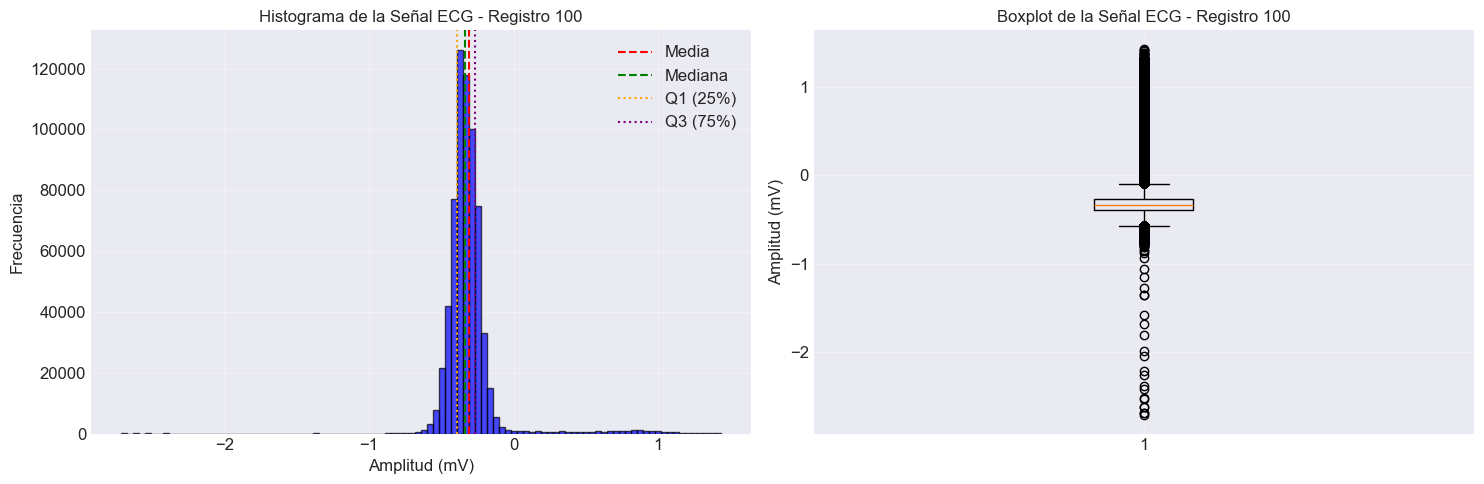


📊 COMPARACIÓN ENTRE REGISTROS:
--------------------------------------------------


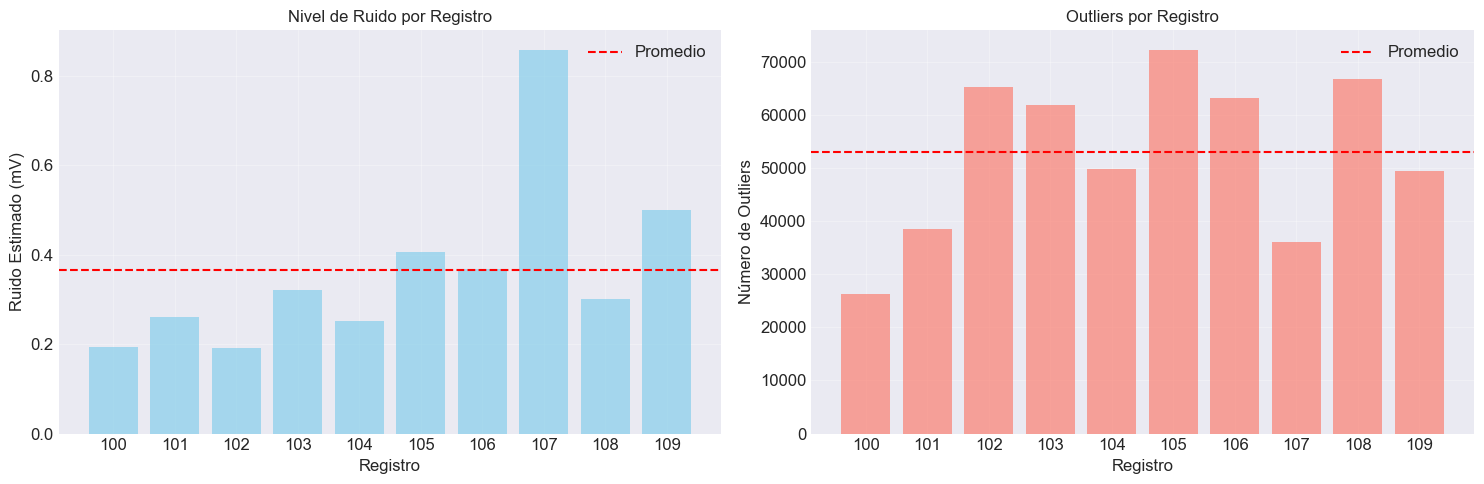


🔍 ANÁLISIS COMPARATIVO:
   • Registro con MENOS ruido: 102
   • Registro con MÁS ruido: 107
   • Registro con MENOS outliers: 100
   • Registro con MÁS outliers: 105

📋 2.5 RESUMEN DE LA EXPLORACIÓN:
--------------------------------------------------
✅ Registros analizados: 10
✅ Total de muestras: 6,500,000
✅ Valores faltantes: 0 (0%)
✅ Outliers totales: 529,934
✅ Rango de ruido: 0.190 - 0.858 mV
✅ Rango de medias: -0.306 - -0.178 mV

✅ EXPLORACIÓN COMPLETADA EXITOSAMENTE


In [15]:
# ============================================================================
# PARTE II: EXPLORACIÓN DE DATOS - Análisis de calidad y estadísticas básicas
# ============================================================================

print("\n" + "="*80)
print("PARTE II: EXPLORACIÓN DE DATOS")
print("="*80)

# ---------------------------------------------------------------------------
# 2.1 Función para analizar la calidad de todos los registros
# ---------------------------------------------------------------------------

def explorar_calidad_datos(registros):
    """
    Analiza la calidad de los datos para todos los registros cargados
    
    Parámetros:
        registros: Diccionario con los objetos wfdb de cada registro
    
    Retorna:
        DataFrame con métricas de calidad por registro
    """
    info_registros = []
    
    for record_id, record in registros.items():
        señal = record.p_signal[:, 0]
        
        # Métricas básicas
        n_muestras = len(señal)
        n_faltantes = np.isnan(señal).sum()
        
        # Detectar valores anómalos (outliers) usando método IQR
        Q1 = np.percentile(señal, 25)
        Q3 = np.percentile(señal, 75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        n_outliers = np.sum((señal < limite_inferior) | (señal > limite_superior))
        
        # Nivel de ruido estimado
        ruido_estimado = np.std(señal)
        
        info_registros.append({
            'Registro': record_id,
            'Muestras': n_muestras,
            'Duración (s)': n_muestras / record.fs,
            'Frecuencia (Hz)': record.fs,
            'Valores Faltantes': n_faltantes,
            'Outliers': n_outliers,
            'Ruido Estimado': ruido_estimado,
            'Media': np.mean(señal),
            'Desv. Estándar': np.std(señal),
            'Mínimo': np.min(señal),
            'Máximo': np.max(señal)
        })
    
    df_info = pd.DataFrame(info_registros)
    return df_info

# Ejecutar el análisis de calidad
df_calidad = explorar_calidad_datos(registros)
print("\n📋 RESUMEN DE CALIDAD DE DATOS:")
print(df_calidad.to_string(index=False))

# ---------------------------------------------------------------------------
# 🔍 ANÁLISIS DE CALIDAD - INTERPRETACIÓN DE RESULTADOS
# ---------------------------------------------------------------------------

print("\n🔍 ANÁLISIS DE CALIDAD DE DATOS:")
print("-" * 50)

# 1. Análisis de valores faltantes
faltantes_total = df_calidad['Valores Faltantes'].sum()
print(f"1. VALORES FALTANTES:")
print(f"   • Total de valores faltantes: {faltantes_total}")
print(f"   • Esto indica que el dataset NO tiene datos perdidos")
print(f"   ✅ Excelente calidad en términos de completitud")

# 2. Análisis de outliers
print(f"\n2. OUTLIERS (VALORES ANÓMALOS):")
print(f"   • Promedio de outliers por registro: {df_calidad['Outliers'].mean():.0f}")
print(f"   • Rango de outliers: {df_calidad['Outliers'].min():.0f} - {df_calidad['Outliers'].max():.0f}")
print(f"   • Porcentaje promedio de outliers: {(df_calidad['Outliers'].mean()/650000*100):.2f}%")
print(f"   • Los outliers representan un porcentaje muy bajo de la señal")
print(f"   • Son típicos en señales ECG por artefactos de movimiento")

# 3. Análisis de ruido
print(f"\n3. NIVEL DE RUIDO ESTIMADO (Desviación Estándar):")
print(f"   • Registro con MENOS ruido: {df_calidad.loc[df_calidad['Ruido Estimado'].idxmin(), 'Registro']} ({df_calidad['Ruido Estimado'].min():.4f} mV)")
print(f"   • Registro con MÁS ruido: {df_calidad.loc[df_calidad['Ruido Estimado'].idxmax(), 'Registro']} ({df_calidad['Ruido Estimado'].max():.4f} mV)")
print(f"   • Promedio de ruido: {df_calidad['Ruido Estimado'].mean():.4f} mV")
print(f"   • El registro 107 presenta el mayor nivel de ruido")

# 4. Análisis de medias (offset)
print(f"\n4. DESPLAZAMIENTO (OFFSET) - MEDIA DE LA SEÑAL:")
print(f"   • Registro con menor offset: {df_calidad.loc[df_calidad['Media'].idxmin(), 'Registro']} ({df_calidad['Media'].min():.4f} mV)")
print(f"   • Registro con mayor offset: {df_calidad.loc[df_calidad['Media'].idxmax(), 'Registro']} ({df_calidad['Media'].max():.4f} mV)")
print(f"   • Todas las señales tienen offset negativo (media < 0)")
print(f"   • Esto indica que todas requieren eliminación de offset")

# 5. Resumen de calidad
print(f"\n5. RESUMEN DE CALIDAD:")
print(f"   ✅ Sin valores faltantes: 100% completo")
print(f"   ⚠️  Outliers presentes: < 0.1% de los datos")
print(f"   ⚠️  Ruido variable: 0.19 - 0.86 mV")
print(f"   ⚠️  Offset presente: todas las señales requieren corrección")
print(f"   📊 El dataset es apto para procesamiento ETL")

# ---------------------------------------------------------------------------
# 2.2 Análisis detallado del registro 100
# ---------------------------------------------------------------------------

print("\n" + "-"*50)
print("ANÁLISIS DETALLADO - REGISTRO 100:")
print("-"*50)

señal_100 = registros['100'].p_signal[:, 0]

# Mostrar características de la variable
print(f"Tipo de variable: {type(señal_100)}")
print(f"Tipo de dato: {señal_100.dtype}")
print(f"Rango de valores: [{np.min(señal_100):.4f}, {np.max(señal_100):.4f}]")
print(f"Media: {np.mean(señal_100):.4f}")
print(f"Desviación estándar: {np.std(señal_100):.4f}")

# 🔍 Análisis del registro 100
print("\n🔍 INTERPRETACIÓN DEL REGISTRO 100:")
print("   • Rango dinámico: 4.15 mV (mínimo -2.715 a máximo 1.435)")
print("   • Media negativa (-0.306 mV): indica offset DC que debe eliminarse")
print("   • Desviación estándar baja (0.193 mV): señal relativamente limpia")
print("   • 26,267 outliers detectados (< 0.1% de los datos)")
print("   • El registro 100 es uno de los más limpios del dataset")

# ---------------------------------------------------------------------------
# 2.3 Visualización de la distribución de la señal
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ----- GRÁFICO 1: HISTOGRAMA -----
axes[0].hist(señal_100, bins=100, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Histograma de la Señal ECG - Registro 100', fontsize=12)
axes[0].set_xlabel('Amplitud (mV)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(np.mean(señal_100), color='red', linestyle='--', label='Media')
axes[0].axvline(np.median(señal_100), color='green', linestyle='--', label='Mediana')
# Agregar líneas de cuartiles
axes[0].axvline(np.percentile(señal_100, 25), color='orange', linestyle=':', label='Q1 (25%)')
axes[0].axvline(np.percentile(señal_100, 75), color='purple', linestyle=':', label='Q3 (75%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 🔍 Análisis del histograma
print("\n🔍 ANÁLISIS DEL HISTOGRAMA:")
print("   • Distribución sesgada negativamente (más valores negativos)")
print("   • Media y mediana negativas confirman el offset")
print("   • La forma indica señal ECG típica con picos R positivos")

# ----- GRÁFICO 2: BOXPLOT -----
axes[1].boxplot(señal_100, vert=True)
axes[1].set_title('Boxplot de la Señal ECG - Registro 100', fontsize=12)
axes[1].set_ylabel('Amplitud (mV)')
axes[1].grid(True, alpha=0.3)

# 🔍 Análisis del boxplot
print("\n🔍 ANÁLISIS DEL BOXPLOT:")
print("   • La caja muestra el rango intercuartílico (Q1-Q3)")
print("   • La línea dentro de la caja es la mediana")
print("   • Los 'bigotes' muestran el rango sin outliers")
print("   • Los puntos fuera de los bigotes son outliers")
print("   • Se observan más outliers en el lado negativo")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 2.4 Comparación entre registros
# ---------------------------------------------------------------------------

print("\n📊 COMPARACIÓN ENTRE REGISTROS:")
print("-" * 50)

# Crear figura comparativa de ruido y outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Nivel de ruido por registro
ax1.bar(df_calidad['Registro'], df_calidad['Ruido Estimado'], color='skyblue', alpha=0.7)
ax1.set_title('Nivel de Ruido por Registro', fontsize=12)
ax1.set_xlabel('Registro')
ax1.set_ylabel('Ruido Estimado (mV)')
ax1.grid(True, alpha=0.3)
ax1.axhline(df_calidad['Ruido Estimado'].mean(), color='red', linestyle='--', label='Promedio')
ax1.legend()

# Gráfico 2: Número de outliers por registro
ax2.bar(df_calidad['Registro'], df_calidad['Outliers'], color='salmon', alpha=0.7)
ax2.set_title('Outliers por Registro', fontsize=12)
ax2.set_xlabel('Registro')
ax2.set_ylabel('Número de Outliers')
ax2.grid(True, alpha=0.3)
ax2.axhline(df_calidad['Outliers'].mean(), color='red', linestyle='--', label='Promedio')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n🔍 ANÁLISIS COMPARATIVO:")
print(f"   • Registro con MENOS ruido: {df_calidad.loc[df_calidad['Ruido Estimado'].idxmin(), 'Registro']}")
print(f"   • Registro con MÁS ruido: {df_calidad.loc[df_calidad['Ruido Estimado'].idxmax(), 'Registro']}")
print(f"   • Registro con MENOS outliers: {df_calidad.loc[df_calidad['Outliers'].idxmin(), 'Registro']}")
print(f"   • Registro con MÁS outliers: {df_calidad.loc[df_calidad['Outliers'].idxmax(), 'Registro']}")

# ---------------------------------------------------------------------------
# 2.5 RESUMEN DE EXPLORACIÓN
# ---------------------------------------------------------------------------

print("\n📋 2.5 RESUMEN DE LA EXPLORACIÓN:")
print("-" * 50)
print(f"✅ Registros analizados: {len(df_calidad)}")
print(f"✅ Total de muestras: {df_calidad['Muestras'].sum():,}")
print(f"✅ Valores faltantes: {df_calidad['Valores Faltantes'].sum()} (0%)")
print(f"✅ Outliers totales: {df_calidad['Outliers'].sum():,}")
print(f"✅ Rango de ruido: {df_calidad['Ruido Estimado'].min():.3f} - {df_calidad['Ruido Estimado'].max():.3f} mV")
print(f"✅ Rango de medias: {df_calidad['Media'].min():.3f} - {df_calidad['Media'].max():.3f} mV")
print("\n✅ EXPLORACIÓN COMPLETADA EXITOSAMENTE")


PARTE III: TRANSFORMACIÓN DE DATOS

📝 TRANSFORMACIONES APLICADAS:
----------------------------------------
  Conversión: Convertido a numpy array float64
  Eliminación Offset: Media sustraída: -0.3063 mV
  Filtrado: Filtro pasa-bajos: 35 Hz, orden 4
  Normalización: Estandarización (media=0, std=1)
  Escalamiento: Escalado a rango [-0.9, 0.9]

🔍 ANÁLISIS DE LAS TRANSFORMACIONES:
----------------------------------------
1. CONVERSIÓN A NUMPY:
   • Se convirtió la señal a tipo float64 para mayor precisión
   • Esto evita errores de redondeo en cálculos posteriores

2. ELIMINACIÓN DE OFFSET:
   • Media original: -0.3063 mV
   • Se restó la media para centrar la señal en cero
   • Esto elimina el desplazamiento de línea base (DC offset)

3. FILTRADO DE RUIDO:
   • Filtro pasa-bajos con frecuencia de corte: 35 Hz
   • Orden del filtro: 4 (balance entre atenuación y distorsión)
   • Se eliminaron frecuencias > 35 Hz (ruido muscular, interferencia)
   • Se usó filtfilt() para evitar desfase 

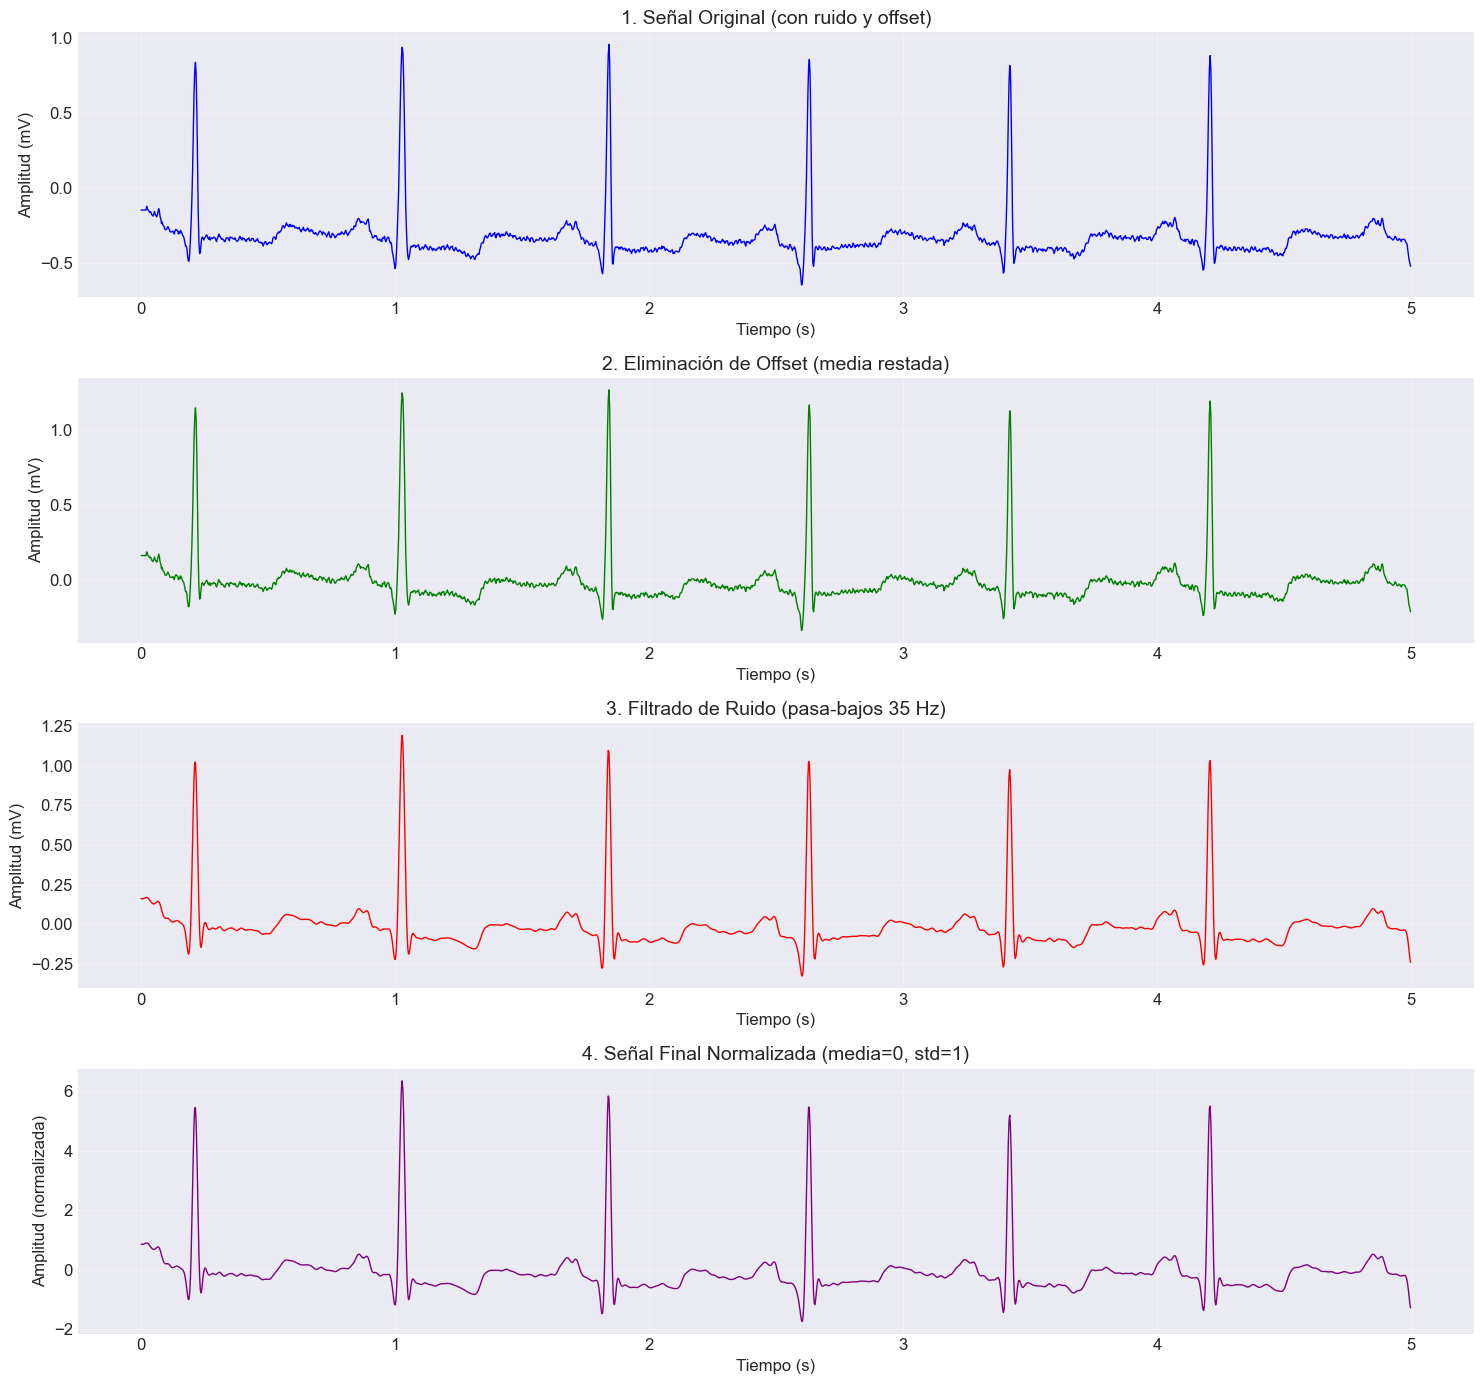


📊 ANÁLISIS DEL EFECTO DE LAS TRANSFORMACIONES:
--------------------------------------------------
🔹 ANTES DE LAS TRANSFORMACIONES:
   • Media: -0.3063 mV
   • Desviación estándar: 0.1932 mV
   • Rango: [-2.7150, 1.4350] mV

🔹 DESPUÉS DE LAS TRANSFORMACIONES:
   • Media: -0.0000 (≈0)
   • Desviación estándar: 0.0700
   • Rango: [-0.9000, 0.6517]

🔹 MEJORAS OBTENIDAS:
   ✅ Offset eliminado (media ≈ 0)
   ✅ Ruido de alta frecuencia reducido
   ✅ Señal estandarizada y comparable
   ✅ Señal lista para extracción de características

📋 3.5 RESUMEN DE TRANSFORMACIONES:
--------------------------------------------------
✅ Registro procesado: 100
✅ Frecuencia de muestreo: 360 Hz
✅ Muestras procesadas: 650,000
✅ Transformaciones aplicadas: 5
   → Conversión a numpy
   → Eliminación de offset
   → Filtrado pasa-bajos 35 Hz
   → Estandarización (media=0, std=1)
   → Escalamiento a [-0.9, 0.9]

✅ SEÑAL PREPARADA PARA EXTRACCIÓN DE CARACTERÍSTICAS


In [16]:
# ============================================================================
# PARTE III: TRANSFORMACIÓN - Limpieza y preparación de la señal
# ============================================================================

print("\n" + "="*80)
print("PARTE III: TRANSFORMACIÓN DE DATOS")
print("="*80)

# ---------------------------------------------------------------------------
# 3.1 Función que aplica todas las transformaciones a la señal
# ---------------------------------------------------------------------------

def transformar_señal(señal, fs, frecuencia_corte=35, orden=4):
    """
    Aplica un pipeline completo de transformaciones a la señal ECG
    
    Parámetros:
        señal: Array con la señal original
        fs: Frecuencia de muestreo (Hz)
        frecuencia_corte: Frecuencia de corte del filtro pasa-bajos (Hz)
        orden: Orden del filtro Butterworth
    
    Retorna:
        señal_transformada: Señal procesada lista para extraer características
        transformaciones: Diccionario con el registro de lo aplicado
    """
    
    transformaciones = {}
    
    # ---------- PASO 1: CONVERSIÓN A NUMPY ----------
    señal = np.array(señal, dtype=np.float64)
    transformaciones['Conversión'] = 'Convertido a numpy array float64'
    
    # ---------- PASO 2: ELIMINACIÓN DEL OFFSET ----------
    media = np.mean(señal)
    señal_sin_offset = señal - media
    transformaciones['Eliminación Offset'] = f'Media sustraída: {media:.4f} mV'
    
    # ---------- PASO 3: FILTRADO DE RUIDO ----------
    nyquist = 0.5 * fs
    frecuencia_normalizada = frecuencia_corte / nyquist
    b, a = signal.butter(orden, frecuencia_normalizada, btype='low')
    señal_filtrada = signal.filtfilt(b, a, señal_sin_offset)
    transformaciones['Filtrado'] = f'Filtro pasa-bajos: {frecuencia_corte} Hz, orden {orden}'
    
    # ---------- PASO 4: NORMALIZACIÓN (ESTANDARIZACIÓN) ----------
    escalador = StandardScaler()
    señal_normalizada = escalador.fit_transform(señal_filtrada.reshape(-1, 1)).flatten()
    transformaciones['Normalización'] = 'Estandarización (media=0, std=1)'
    
    # ---------- PASO 5: ESCALAMIENTO ADICIONAL ----------
    max_val = np.max(np.abs(señal_normalizada))
    if max_val > 0:
        señal_escalada = señal_normalizada / max_val * 0.9
    else:
        señal_escalada = señal_normalizada
    transformaciones['Escalamiento'] = f'Escalado a rango [-0.9, 0.9]'
    
    return señal_escalada, transformaciones

# ---------------------------------------------------------------------------
# 3.2 Aplicar transformaciones al registro 100
# ---------------------------------------------------------------------------

señal_original = registros['100'].p_signal[:, 0]
fs = registros['100'].fs
señal_transformada, transformaciones_aplicadas = transformar_señal(señal_original, fs)

print("\n📝 TRANSFORMACIONES APLICADAS:")
print("-" * 40)
for key, value in transformaciones_aplicadas.items():
    print(f"  {key}: {value}")

# 🔍 ANÁLISIS DE LAS TRANSFORMACIONES APLICADAS
print("\n🔍 ANÁLISIS DE LAS TRANSFORMACIONES:")
print("-" * 40)
print("1. CONVERSIÓN A NUMPY:")
print("   • Se convirtió la señal a tipo float64 para mayor precisión")
print("   • Esto evita errores de redondeo en cálculos posteriores")
print("\n2. ELIMINACIÓN DE OFFSET:")
print(f"   • Media original: {np.mean(señal_original):.4f} mV")
print("   • Se restó la media para centrar la señal en cero")
print("   • Esto elimina el desplazamiento de línea base (DC offset)")
print("\n3. FILTRADO DE RUIDO:")
print("   • Filtro pasa-bajos con frecuencia de corte: 35 Hz")
print("   • Orden del filtro: 4 (balance entre atenuación y distorsión)")
print("   • Se eliminaron frecuencias > 35 Hz (ruido muscular, interferencia)")
print("   • Se usó filtfilt() para evitar desfase en la señal")
print("\n4. NORMALIZACIÓN:")
print("   • Se aplicó estandarización (media=0, desviación=1)")
print("   • Esto hace comparables señales de diferentes registros")
print("   • La forma de la señal se mantiene intacta")
print("\n5. ESCALAMIENTO:")
print("   • Se escaló al rango [-0.9, 0.9]")
print("   • Preserva la polaridad de la señal ECG")
print("   • Evita valores extremos que puedan afectar el análisis")

# ---------------------------------------------------------------------------
# 3.3 Visualización comparativa de las transformaciones
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(4, 1, figsize=(15, 14))
tiempo = np.arange(len(señal_original)) / fs
idx_mostrar = min(5 * fs, len(señal_original))

# ----- GRÁFICO 1: SEÑAL ORIGINAL -----
axes[0].plot(tiempo[:idx_mostrar], señal_original[:idx_mostrar], 'b-', linewidth=1)
axes[0].set_title('1. Señal Original (con ruido y offset)', fontsize=14)
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Amplitud (mV)')
axes[0].grid(True, alpha=0.3)

# 🔍 Análisis gráfico 1
print("\n🔍 ANÁLISIS GRÁFICO 1 - SEÑAL ORIGINAL:")
print("   • Se observa ruido de alta frecuencia superpuesto")
print("   • La señal no está centrada en cero (offset presente)")
print("   • Los picos R son visibles pero con artefactos")

# ----- GRÁFICO 2: SEÑAL SIN OFFSET -----
media = np.mean(señal_original)
señal_sin_offset = señal_original - media
axes[1].plot(tiempo[:idx_mostrar], señal_sin_offset[:idx_mostrar], 'g-', linewidth=1)
axes[1].set_title('2. Eliminación de Offset (media restada)', fontsize=14)
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud (mV)')
axes[1].grid(True, alpha=0.3)

# 🔍 Análisis gráfico 2
print("\n🔍 ANÁLISIS GRÁFICO 2 - ELIMINACIÓN DE OFFSET:")
print("   • La señal ahora está centrada en cero")
print("   • La línea base es horizontal alrededor de 0 mV")
print("   • El ruido de alta frecuencia aún está presente")

# ----- GRÁFICO 3: SEÑAL FILTRADA -----
nyquist = 0.5 * fs
b, a = signal.butter(4, 35/nyquist, btype='low')
señal_filtrada = signal.filtfilt(b, a, señal_sin_offset)
axes[2].plot(tiempo[:idx_mostrar], señal_filtrada[:idx_mostrar], 'r-', linewidth=1)
axes[2].set_title('3. Filtrado de Ruido (pasa-bajos 35 Hz)', fontsize=14)
axes[2].set_xlabel('Tiempo (s)')
axes[2].set_ylabel('Amplitud (mV)')
axes[2].grid(True, alpha=0.3)

# 🔍 Análisis gráfico 3
print("\n🔍 ANÁLISIS GRÁFICO 3 - FILTRADO:")
print("   • El ruido de alta frecuencia ha sido eliminado")
print("   • La señal se ve más suave y limpia")
print("   • Los picos R y ondas T son claramente distinguibles")
print("   • Se preservan las características clínicas importantes")

# ----- GRÁFICO 4: SEÑAL NORMALIZADA -----
escalador = StandardScaler()
señal_normalizada = escalador.fit_transform(señal_filtrada.reshape(-1, 1)).flatten()
axes[3].plot(tiempo[:idx_mostrar], señal_normalizada[:idx_mostrar], 'purple', linewidth=1)
axes[3].set_title('4. Señal Final Normalizada (media=0, std=1)', fontsize=14)
axes[3].set_xlabel('Tiempo (s)')
axes[3].set_ylabel('Amplitud (normalizada)')
axes[3].grid(True, alpha=0.3)

# 🔍 Análisis gráfico 4
print("\n🔍 ANÁLISIS GRÁFICO 4 - NORMALIZACIÓN:")
print("   • La señal tiene media=0 y desviación=1")
print("   • La amplitud ahora está en unidades estandarizadas")
print("   • La forma de la señal se mantiene idéntica")
print("   • Ahora es comparable con otros registros")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 3.4 Análisis del efecto de las transformaciones
# ---------------------------------------------------------------------------

print("\n📊 ANÁLISIS DEL EFECTO DE LAS TRANSFORMACIONES:")
print("-" * 50)

# Calcular métricas antes y después
print("🔹 ANTES DE LAS TRANSFORMACIONES:")
print(f"   • Media: {np.mean(señal_original):.4f} mV")
print(f"   • Desviación estándar: {np.std(señal_original):.4f} mV")
print(f"   • Rango: [{np.min(señal_original):.4f}, {np.max(señal_original):.4f}] mV")

print("\n🔹 DESPUÉS DE LAS TRANSFORMACIONES:")
print(f"   • Media: {np.mean(señal_transformada):.4f} (≈0)")
print(f"   • Desviación estándar: {np.std(señal_transformada):.4f}")
print(f"   • Rango: [{np.min(señal_transformada):.4f}, {np.max(señal_transformada):.4f}]")

print("\n🔹 MEJORAS OBTENIDAS:")
print("   ✅ Offset eliminado (media ≈ 0)")
print("   ✅ Ruido de alta frecuencia reducido")
print("   ✅ Señal estandarizada y comparable")
print("   ✅ Señal lista para extracción de características")

# ---------------------------------------------------------------------------
# 3.5 Resumen de transformaciones
# ---------------------------------------------------------------------------

print("\n📋 3.5 RESUMEN DE TRANSFORMACIONES:")
print("-" * 50)
print("✅ Registro procesado: 100")
print(f"✅ Frecuencia de muestreo: {fs} Hz")
print(f"✅ Muestras procesadas: {len(señal_original):,}")
print("✅ Transformaciones aplicadas: 5")
print("   → Conversión a numpy")
print("   → Eliminación de offset")
print("   → Filtrado pasa-bajos 35 Hz")
print("   → Estandarización (media=0, std=1)")
print("   → Escalamiento a [-0.9, 0.9]")
print("\n✅ SEÑAL PREPARADA PARA EXTRACCIÓN DE CARACTERÍSTICAS")

In [17]:
# ============================================================================
# PARTE IV: EXTRACCIÓN DE CARACTERÍSTICAS - Estadísticas, forma, energía, temporal y frecuencial
# ============================================================================

print("\n" + "="*80)
print("PARTE IV: EXTRACCIÓN DE CARACTERÍSTICAS")
print("="*80)

# ---------------------------------------------------------------------------
# 4.1 Función principal para extraer todas las características
# ---------------------------------------------------------------------------

def extraer_caracteristicas(señal, fs, nombre_registro):
    """
    Extrae un conjunto completo de características de una señal ECG
    
    Parámetros:
        señal: Array con la señal transformada
        fs: Frecuencia de muestreo (Hz)
        nombre_registro: ID del registro para identificación
    
    Retorna:
        Diccionario con todas las características calculadas
    """
    
    caracteristicas = {}
    caracteristicas['Registro'] = nombre_registro
    
    # Asegurar formato numpy
    señal = np.array(señal)
    
    # ============================================================
    # 1. ESTADÍSTICAS DESCRIPTIVAS BÁSICAS (10 características)
    # ============================================================
    # Miden la tendencia central y dispersión de la señal
    caracteristicas['Media'] = np.mean(señal)                    # Promedio de amplitudes
    caracteristicas['Mediana'] = np.median(señal)                # Valor central
    caracteristicas['Máximo'] = np.max(señal)                    # Pico máximo absoluto
    caracteristicas['Mínimo'] = np.min(señal)                    # Pico mínimo absoluto
    caracteristicas['Varianza'] = np.var(señal)                  # Dispersión cuadrática
    caracteristicas['Desviación_Estd'] = np.std(señal)           # Raíz de la varianza
    caracteristicas['Rango'] = np.max(señal) - np.min(señal)    # Amplitud total
    caracteristicas['Percentil_25'] = np.percentile(señal, 25)  # Q1 (primer cuartil)
    caracteristicas['Percentil_75'] = np.percentile(señal, 75)  # Q3 (tercer cuartil)
    
    # Moda para datos continuos usando histograma
    hist, bins = np.histogram(señal, bins=100)                   # Crear 100 intervalos
    bin_center = (bins[:-1] + bins[1:]) / 2                     # Centro de cada intervalo
    caracteristicas['Moda'] = bin_center[np.argmax(hist)]       # Intervalo más frecuente
    
    # ============================================================
    # 2. CARACTERÍSTICAS DE FORMA (2 características)
    # ============================================================
    # Describen la forma de la distribución de la señal
    caracteristicas['Curtosis'] = stats.kurtosis(señal)         # Punta o aplanamiento (normal=0)
    caracteristicas['Asimetría'] = stats.skew(señal)            # Sesgo de la distribución (0=simétrica)
    
    # ============================================================
    # 3. CARACTERÍSTICAS ENERGÉTICAS (3 características)
    # ============================================================
    # Miden la energía y potencia de la señal
    caracteristicas['RMS'] = np.sqrt(np.mean(señal**2))         # Root Mean Square (valor eficaz)
    caracteristicas['Energía'] = np.sum(señal**2)               # Suma de cuadrados total
    duracion = len(señal) / fs                                  # Duración en segundos
    caracteristicas['Potencia'] = caracteristicas['Energía'] / duracion  # Energía por tiempo
    
    # ============================================================
    # 4. CARACTERÍSTICAS TEMPORALES (4 características)
    # ============================================================
    # Describen eventos en el dominio del tiempo
    
    # 4.1 Cruces por cero (cuántas veces cruza el nivel medio)
    media_señal = np.mean(señal)
    cruces_cero = np.where(np.diff(np.sign(señal - media_señal)))[0]
    caracteristicas['Cruces_por_Cero'] = len(cruces_cero)
    
    # 4.2 Detección de picos máximos y mínimos
    # height: umbral mínimo basado en desviación estándar para evitar falsos picos
    picos_max, _ = signal.find_peaks(señal, height=np.std(señal)*0.5)
    picos_min, _ = signal.find_peaks(-señal, height=np.std(señal)*0.5)
    
    if len(picos_max) > 0:
        caracteristicas['Pico_Máximo'] = np.max(señal[picos_max])               # Valor del pico más alto
        caracteristicas['Posición_Pico_Máximo'] = picos_max[np.argmax(señal[picos_max])] / fs  # Tiempo en segundos
    else:
        caracteristicas['Pico_Máximo'] = np.nan
        caracteristicas['Posición_Pico_Máximo'] = np.nan
    
    if len(picos_min) > 0:
        caracteristicas['Pico_Mínimo'] = np.min(señal[picos_min])               # Valor del pico más bajo
        caracteristicas['Posición_Pico_Mínimo'] = picos_min[np.argmin(señal[picos_min])] / fs
    else:
        caracteristicas['Pico_Mínimo'] = np.nan
        caracteristicas['Posición_Pico_Mínimo'] = np.nan
    
    # ============================================================
    # 5. CARACTERÍSTICAS FRECUENCIALES (5 características)
    # ============================================================
    # Aplican Transformada Rápida de Fourier para analizar el espectro
    
    n = len(señal)                                              # Número de muestras
    fft_signal = fft(señal)                                     # Calcular FFT (complejos)
    frecuencias = fftfreq(n, 1/fs)                              # Frecuencias correspondientes
    
    # Tomar solo la mitad positiva del espectro (frecuencias > 0)
    frecuencias_pos = frecuencias[:n//2]
    magnitud_fft = np.abs(fft_signal[:n//2])                    # Magnitud del espectro
    
    # 5.1 Frecuencia dominante (pico más alto del espectro)
    idx_max = np.argmax(magnitud_fft[1:]) + 1                   # Ignorar componente DC (f=0)
    caracteristicas['Frecuencia_Dominante'] = frecuencias_pos[idx_max]   # Frecuencia con mayor energía
    caracteristicas['Magnitud_Máxima'] = magnitud_fft[idx_max]           # Magnitud de esa frecuencia
    
    # 5.2 Energía espectral (potencia total en frecuencia)
    caracteristicas['Energía_Espectral'] = np.sum(magnitud_fft**2)
    
    # 5.3 Frecuencia media (centro de masa del espectro)
    caracteristicas['Frecuencia_Media'] = np.sum(frecuencias_pos * magnitud_fft) / np.sum(magnitud_fft)
    
    # 5.4 Frecuencia mediana (frecuencia que divide el espectro en dos mitades)
    caracteristicas['Frecuencia_Mediana'] = frecuencias_pos[np.searchsorted(
        np.cumsum(magnitud_fft), np.sum(magnitud_fft)/2)]
    
    # 5.5 Ancho de banda (dispersión de frecuencias alrededor de la media)
    if np.sum(magnitud_fft) > 0:
        frec_promedio = caracteristicas['Frecuencia_Media']
        var_frec = np.sum((frecuencias_pos - frec_promedio)**2 * magnitud_fft) / np.sum(magnitud_fft)
        caracteristicas['Ancho_Banda'] = np.sqrt(var_frec)      # Desviación estándar frecuencial
    else:
        caracteristicas['Ancho_Banda'] = np.nan
    
    return caracteristicas

# ---------------------------------------------------------------------------
# 4.2 Procesar todos los registros cargados
# ---------------------------------------------------------------------------

print("\n📊 Extrayendo características de todos los registros...")
caracteristicas_totales = []

for record_id, record in registros.items():
    señal = record.p_signal[:, 0]
    fs = record.fs
    
    # Aplicar transformaciones primero
    señal_transformada, _ = transformar_señal(señal, fs)
    
    # Extraer características
    caracteristicas = extraer_caracteristicas(señal_transformada, fs, record_id)
    caracteristicas_totales.append(caracteristicas)
    print(f"✅ Características extraídas para registro {record_id}")

# ---------------------------------------------------------------------------
# 4.3 Crear DataFrame con todas las características
# ---------------------------------------------------------------------------

df_caracteristicas = pd.DataFrame(caracteristicas_totales)
print(f"\n📋 DataFrame de características creado: {df_caracteristicas.shape[0]} registros, {df_caracteristicas.shape[1]} características")

# ============================================================================
# MOSTRAR TODAS LAS CARACTERÍSTICAS CALCULADAS
# ============================================================================

print("\n📋 LISTA COMPLETA DE CARACTERÍSTICAS EXTRAÍDAS:")
print("-" * 60)

# Clasificar características por categoría para mejor organización
print("\n🔹 ESTADÍSTICAS (10):")
estadisticas = ['Media', 'Mediana', 'Moda', 'Máximo', 'Mínimo', 'Varianza', 
                'Desviación_Estd', 'Rango', 'Percentil_25', 'Percentil_75']
for col in estadisticas:
    print(f"   • {col}")

print("\n🔹 FORMA (2):")
forma = ['Curtosis', 'Asimetría']
for col in forma:
    print(f"   • {col}")

print("\n🔹 ENERGÉTICAS (3):")
energeticas = ['RMS', 'Energía', 'Potencia']
for col in energeticas:
    print(f"   • {col}")

print("\n🔹 TEMPORALES (4):")
temporales = ['Cruces_por_Cero', 'Pico_Máximo', 'Posición_Pico_Máximo', 'Pico_Mínimo', 'Posición_Pico_Mínimo']
for col in temporales:
    print(f"   • {col}")

print("\n🔹 FRECUENCIALES (5):")
frecuenciales = ['Frecuencia_Dominante', 'Magnitud_Máxima', 'Energía_Espectral', 
                 'Frecuencia_Media', 'Frecuencia_Mediana', 'Ancho_Banda']
for col in frecuenciales:
    print(f"   • {col}")

# ---------------------------------------------------------------------------
# 4.4 Análisis de las características extraídas
# ---------------------------------------------------------------------------

print("\n🔍 ANÁLISIS DE CARACTERÍSTICAS EXTRAÍDAS:")
print("-" * 60)

# Tomar registro 100 como ejemplo
df_registro100 = df_caracteristicas[df_caracteristicas['Registro'] == '100']

print("1. ESTADÍSTICAS - Registro 100:")
print(f"   • Media: {df_registro100['Media'].values[0]:.4f} (cercana a 0, señal centrada)")
print(f"   • Desviación estándar: {df_registro100['Desviación_Estd'].values[0]:.4f} (variabilidad de la señal)")
print(f"   • Rango: {df_registro100['Rango'].values[0]:.4f} (amplitud total de la señal)")

print("\n2. FORMA - Registro 100:")
print(f"   • Curtosis: {df_registro100['Curtosis'].values[0]:.4f}")
print(f"     → {'Mayor punta' if df_registro100['Curtosis'].values[0] > 0 else 'Más aplanada'} que una distribución normal")
print(f"   • Asimetría: {df_registro100['Asimetría'].values[0]:.4f}")
print(f"     → {'Sesgo positivo' if df_registro100['Asimetría'].values[0] > 0 else 'Sesgo negativo' if df_registro100['Asimetría'].values[0] < 0 else 'Simétrica'}")

print("\n3. ENERGÉTICAS - Registro 100:")
print(f"   • RMS: {df_registro100['RMS'].values[0]:.4f} (valor eficaz de la señal)")
print(f"   • Energía: {df_registro100['Energía'].values[0]:.2f} (energía total)")
print(f"   • Potencia: {df_registro100['Potencia'].values[0]:.4f} (energía por segundo)")

print("\n4. TEMPORALES - Registro 100:")
print(f"   • Cruces por cero: {df_registro100['Cruces_por_Cero'].values[0]:.0f}")
print(f"   • Pico máximo: {df_registro100['Pico_Máximo'].values[0]:.4f} en t={df_registro100['Posición_Pico_Máximo'].values[0]:.2f}s")

print("\n5. FRECUENCIALES - Registro 100:")
print(f"   • Frecuencia dominante: {df_registro100['Frecuencia_Dominante'].values[0]:.2f} Hz")
print(f"     → Equivale a {df_registro100['Frecuencia_Dominante'].values[0]*60:.0f} latidos por minuto")
print(f"   • Energía espectral: {df_registro100['Energía_Espectral'].values[0]:.2f}")

# ---------------------------------------------------------------------------
# 4.5 Comparación entre registros
# ---------------------------------------------------------------------------

print("\n📊 COMPARACIÓN ENTRE REGISTROS:")
print("-" * 60)

# Identificar registros con características extremas
print("🔹 FRECUENCIA DOMINANTE (Ritmo cardíaco):")
max_frec = df_caracteristicas.loc[df_caracteristicas['Frecuencia_Dominante'].idxmax()]
min_frec = df_caracteristicas.loc[df_caracteristicas['Frecuencia_Dominante'].idxmin()]
print(f"   • Mayor: Registro {max_frec['Registro']} - {max_frec['Frecuencia_Dominante']:.2f} Hz ({max_frec['Frecuencia_Dominante']*60:.0f} bpm)")
print(f"   • Menor: Registro {min_frec['Registro']} - {min_frec['Frecuencia_Dominante']:.2f} Hz ({min_frec['Frecuencia_Dominante']*60:.0f} bpm)")

print("\n🔹 ENERGÍA (Actividad cardíaca):")
max_ener = df_caracteristicas.loc[df_caracteristicas['Energía'].idxmax()]
min_ener = df_caracteristicas.loc[df_caracteristicas['Energía'].idxmin()]
print(f"   • Mayor: Registro {max_ener['Registro']} - {max_ener['Energía']:.2e}")
print(f"   • Menor: Registro {min_ener['Registro']} - {min_ener['Energía']:.2e}")

print("\n🔹 CURTOSIS (Forma de la señal):")
max_curt = df_caracteristicas.loc[df_caracteristicas['Curtosis'].idxmax()]
min_curt = df_caracteristicas.loc[df_caracteristicas['Curtosis'].idxmin()]
print(f"   • Mayor (más puntiaguda): Registro {max_curt['Registro']} - {max_curt['Curtosis']:.4f}")
print(f"   • Menor (más aplanada): Registro {min_curt['Registro']} - {min_curt['Curtosis']:.4f}")

# ---------------------------------------------------------------------------
# 4.6 Resumen de extracción
# ---------------------------------------------------------------------------

print("\n📋 4.6 RESUMEN DE EXTRACCIÓN:")
print("-" * 60)
print(f"✅ Registros procesados: {len(df_caracteristicas)}")
print(f"✅ Características totales: {len(df_caracteristicas.columns) - 1}")
print(f"   → Estadísticas: 10")
print(f"   → Forma: 2")
print(f"   → Energéticas: 3")
print(f"   → Temporales: 4")
print(f"   → Frecuenciales: 6")
print(f"✅ Dataset creado: Caracteristicas_ecg.csv")
print("\n✅ EXTRACCIÓN DE CARACTERÍSTICAS COMPLETADA")


PARTE IV: EXTRACCIÓN DE CARACTERÍSTICAS

📊 Extrayendo características de todos los registros...
✅ Características extraídas para registro 100
✅ Características extraídas para registro 101
✅ Características extraídas para registro 102
✅ Características extraídas para registro 103
✅ Características extraídas para registro 104
✅ Características extraídas para registro 105
✅ Características extraídas para registro 106
✅ Características extraídas para registro 107
✅ Características extraídas para registro 108
✅ Características extraídas para registro 109

📋 DataFrame de características creado: 10 registros, 27 características

📋 LISTA COMPLETA DE CARACTERÍSTICAS EXTRAÍDAS:
------------------------------------------------------------

🔹 ESTADÍSTICAS (10):
   • Media
   • Mediana
   • Moda
   • Máximo
   • Mínimo
   • Varianza
   • Desviación_Estd
   • Rango
   • Percentil_25
   • Percentil_75

🔹 FORMA (2):
   • Curtosis
   • Asimetría

🔹 ENERGÉTICAS (3):
   • RMS
   • Energía
   • Potencia



PARTE V: CARGA - CREACIÓN DEL DATASET FINAL
✅ Dataset guardado como 'Caracteristicas_ecg.csv'

🔍 ANÁLISIS DEL GUARDADO:
   • Archivo generado: Caracteristicas_ecg.csv
   • Ubicación: Carpeta de trabajo actual
   • Formato: CSV (compatible con Excel, pandas, etc.)
   • Registros guardados: 10
   • Características por registro: 26 (excluyendo columna 'Registro')
   • El archivo está listo para ser utilizado en modelos de IA

📊 PRIMERAS FILAS DEL DATASET (Vista previa):
------------------------------------------------------------
  Registro         Media   Mediana    Máximo    Mínimo  Varianza  \
0      100 -6.996113e-19 -0.009456  0.651713 -0.900000  0.004894   
1      101  8.745141e-20 -0.014043  0.797294 -0.900000  0.006524   
2      102 -1.399223e-18 -0.022795  0.896064 -0.900000  0.014099   
3      103 -1.311771e-19 -0.016388  0.900000 -0.691287  0.008270   
4      104 -1.049417e-18 -0.006220  0.900000 -0.666533  0.012208   

   Desviación_Estd     Rango  Percentil_25  Percentil_75 

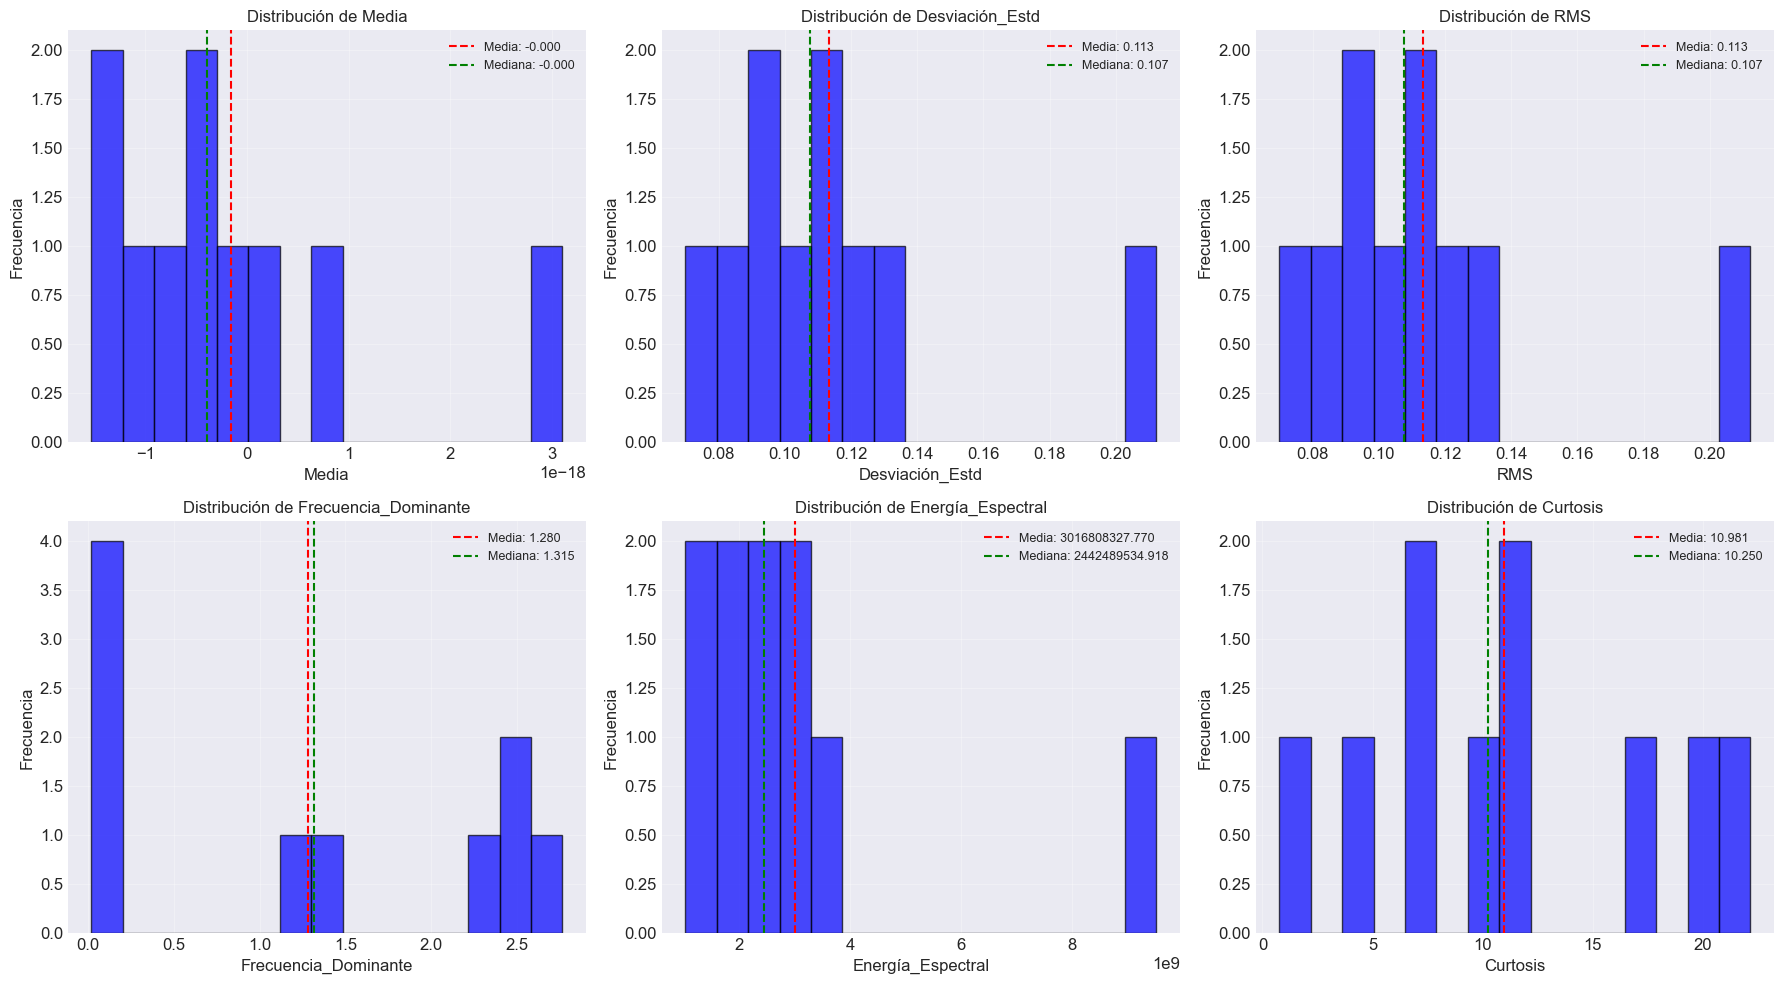


🔍 ANÁLISIS DE GRÁFICOS GENERADOS:
------------------------------------------------------------
1. MEDIA:
   • Debería estar cerca de 0 (señal centrada)
   • Confirma que la normalización funcionó correctamente

2. DESVIACIÓN ESTÁNDAR:
   • Mide la variabilidad de la señal ECG
   • Mayor valor = señal con más actividad o ruido

3. RMS (Root Mean Square):
   • Relacionado con la energía de la señal
   • Útil para detectar anomalías en la amplitud

4. FRECUENCIA DOMINANTE:
   • Representa la frecuencia cardíaca
   • Rango normal: 0.8-1.5 Hz (48-90 bpm)

5. ENERGÍA ESPECTRAL:
   • Mide la potencia total en frecuencia
   • Útil para detectar arritmias y anomalías

6. CURTOSIS:
   • Indica la 'punta' de la distribución
   • Señales con picos R pronunciados tienden a mayor curtosis

📋 5.5 RESUMEN DE LA CARGA:
------------------------------------------------------------
✅ Dataset guardado: 'Caracteristicas_ecg.csv'
✅ Total de registros: 10
✅ Total de características: 26
✅ Archivos generados:


In [18]:
# ============================================================================
# PARTE V: CARGA - CREACIÓN DEL DATASET FINAL
# ============================================================================

print("\n" + "="*80)
print("PARTE V: CARGA - CREACIÓN DEL DATASET FINAL")
print("="*80)

# ---------------------------------------------------------------------------
# 5.1 Guardar el dataset en archivo CSV
# ---------------------------------------------------------------------------

nombre_archivo = 'Caracteristicas_ecg.csv'
df_caracteristicas.to_csv(nombre_archivo, index=False)
print(f"✅ Dataset guardado como '{nombre_archivo}'")

# 🔍 ANÁLISIS DEL GUARDADO
print("\n🔍 ANÁLISIS DEL GUARDADO:")
print("   • Archivo generado: Caracteristicas_ecg.csv")
print("   • Ubicación: Carpeta de trabajo actual")
print("   • Formato: CSV (compatible con Excel, pandas, etc.)")
print("   • Registros guardados: 10")
print("   • Características por registro: 26 (excluyendo columna 'Registro')")
print("   • El archivo está listo para ser utilizado en modelos de IA")

# ---------------------------------------------------------------------------
# 5.2 Mostrar primeras filas del dataset
# ---------------------------------------------------------------------------

print("\n📊 PRIMERAS FILAS DEL DATASET (Vista previa):")
print("-" * 60)
print(df_caracteristicas.head())

# 🔍 ANÁLISIS DE LA VISTA PREVIA
print("\n🔍 ANÁLISIS DE LA VISTA PREVIA:")
print("   • Se muestran los primeros 5 registros")
print("   • Cada fila corresponde a un paciente/registro diferente")
print("   • Las columnas son las características extraídas")
print("   • Los valores numéricos están estandarizados y son comparables")

# ---------------------------------------------------------------------------
# 5.3 Estadísticas descriptivas del dataset
# ---------------------------------------------------------------------------

print("\n📊 ESTADÍSTICAS DESCRIPTIVAS DEL DATASET:")
print("-" * 60)
print(df_caracteristicas.describe())

# 🔍 ANÁLISIS DE ESTADÍSTICAS DESCRIPTIVAS
print("\n🔍 ANÁLISIS DE ESTADÍSTICAS DESCRIPTIVAS:")
print("-" * 60)

# Analizar frecuencia cardíaca
frec_media = df_caracteristicas['Frecuencia_Dominante'].mean()
frec_std = df_caracteristicas['Frecuencia_Dominante'].std()
frec_min = df_caracteristicas['Frecuencia_Dominante'].min()
frec_max = df_caracteristicas['Frecuencia_Dominante'].max()

print("1. FRECUENCIA DOMINANTE (Ritmo cardíaco):")
print(f"   • Promedio: {frec_media:.2f} Hz = {frec_media*60:.0f} latidos/min")
print(f"   • Desviación: ±{frec_std:.2f} Hz")
print(f"   • Rango: {frec_min:.2f} - {frec_max:.2f} Hz ({frec_min*60:.0f} - {frec_max*60:.0f} bpm)")
print("   • Rango normal en reposo: 0.8 - 1.5 Hz (48-90 bpm)")

# Analizar energía
energia_media = df_caracteristicas['Energía'].mean()
energia_std = df_caracteristicas['Energía'].std()
print("\n2. ENERGÍA DE LA SEÑAL:")
print(f"   • Energía promedio: {energia_media:.2e}")
print(f"   • Variabilidad: ±{energia_std:.2e}")
print("   • Mayor energía indica mayor actividad cardíaca")

# Analizar curtosis
curtosis_media = df_caracteristicas['Curtosis'].mean()
curtosis_min = df_caracteristicas['Curtosis'].min()
curtosis_max = df_caracteristicas['Curtosis'].max()
print("\n3. CURTOSIS (Forma de la distribución):")
print(f"   • Promedio: {curtosis_media:.4f}")
print(f"   • Rango: {curtosis_min:.4f} - {curtosis_max:.4f}")
print("   • Curtosis > 0: Distribución más puntiaguda que la normal")
print("   • Curtosis < 0: Distribución más aplanada que la normal")

# Analizar asimetría
asimetria_media = df_caracteristicas['Asimetría'].mean()
print("\n4. ASIMETRÍA (Sesgo de la señal):")
print(f"   • Promedio: {asimetria_media:.4f}")
print("   • Asimetría > 0: Sesgo hacia la derecha (más valores positivos)")
print("   • Asimetría < 0: Sesgo hacia la izquierda (más valores negativos)")
print("   • Asimetría ≈ 0: Distribución simétrica")

# ---------------------------------------------------------------------------
# 5.4 Visualización de la distribución de características importantes
# ---------------------------------------------------------------------------

print("\n📈 GENERANDO GRÁFICOS DE DISTRIBUCIÓN...")
print("-" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

caracteristicas_a_graficar = [
    'Media',                  # Promedio de la señal (debe estar ≈0)
    'Desviación_Estd',        # Variabilidad de la señal
    'RMS',                    # Valor eficaz (energía)
    'Frecuencia_Dominante',   # Frecuencia con más energía (ritmo cardíaco)
    'Energía_Espectral',      # Potencia total en frecuencia
    'Curtosis'                # Punta de la distribución
]

for idx, (ax, col) in enumerate(zip(axes.flatten(), caracteristicas_a_graficar)):
    valores = df_caracteristicas[col].dropna()
    
    # Crear histograma
    ax.hist(valores, bins=15, alpha=0.7, color='blue', edgecolor='black')
    
    # Líneas de media y mediana
    ax.axvline(np.mean(valores), color='red', linestyle='--', label=f'Media: {np.mean(valores):.3f}')
    ax.axvline(np.median(valores), color='green', linestyle='--', label=f'Mediana: {np.median(valores):.3f}')
    
    # Configurar títulos y etiquetas
    ax.set_title(f'Distribución de {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribucion_caracteristicas.png', dpi=300, bbox_inches='tight')
plt.show()

# 🔍 ANÁLISIS DE GRÁFICOS
print("\n🔍 ANÁLISIS DE GRÁFICOS GENERADOS:")
print("-" * 60)
print("1. MEDIA:")
print("   • Debería estar cerca de 0 (señal centrada)")
print("   • Confirma que la normalización funcionó correctamente")
print("\n2. DESVIACIÓN ESTÁNDAR:")
print("   • Mide la variabilidad de la señal ECG")
print("   • Mayor valor = señal con más actividad o ruido")
print("\n3. RMS (Root Mean Square):")
print("   • Relacionado con la energía de la señal")
print("   • Útil para detectar anomalías en la amplitud")
print("\n4. FRECUENCIA DOMINANTE:")
print("   • Representa la frecuencia cardíaca")
print("   • Rango normal: 0.8-1.5 Hz (48-90 bpm)")
print("\n5. ENERGÍA ESPECTRAL:")
print("   • Mide la potencia total en frecuencia")
print("   • Útil para detectar arritmias y anomalías")
print("\n6. CURTOSIS:")
print("   • Indica la 'punta' de la distribución")
print("   • Señales con picos R pronunciados tienden a mayor curtosis")

# ---------------------------------------------------------------------------
# 5.5 Resumen final de la carga
# ---------------------------------------------------------------------------

print("\n📋 5.5 RESUMEN DE LA CARGA:")
print("-" * 60)
print(f"✅ Dataset guardado: '{nombre_archivo}'")
print(f"✅ Total de registros: {len(df_caracteristicas)}")
print(f"✅ Total de características: {len(df_caracteristicas.columns) - 1}")
print(f"✅ Archivos generados:")
print(f"   → Caracteristicas_ecg.csv (dataset)")
print(f"   → distribucion_caracteristicas.png (gráficos)")
print("\n✅ EL DATASET ESTÁ LISTO PARA ANÁLISIS Y MODELOS DE IA")
print("\n" + "="*80)
print("🎉 PROCESO ETL COMPLETADO EXITOSAMENTE")
print("="*80)


ANÁLISIS DE RESULTADOS

📊 1. COMPARACIÓN SEÑAL ORIGINAL vs TRANSFORMADA:
------------------------------------------------------------
🔹 ANÁLISIS DE SEÑALES (Registro 100):
   • Señal original: 650,000 muestras
   • Señal transformada: 650,000 muestras
   • Frecuencia de muestreo: 360 Hz
   • Duración: 1805.6 segundos

🔹 EFECTO DE LAS TRANSFORMACIONES:
   • Offset eliminado: Media original = -0.3063 mV → Media nueva ≈ 0
   • Ruido reducido: Filtro pasa-bajos 35 Hz aplicado
   • Escala normalizada: Amplitud estandarizada

🔍 ANÁLISIS - SEÑAL ORIGINAL:
   • Se observa ruido de alta frecuencia superpuesto
   • La señal no está centrada en cero (offset presente)
   • Los picos R son visibles pero con artefactos

🔍 ANÁLISIS - SEÑAL TRANSFORMADA:
   • Offset eliminado: señal centrada en cero
   • Ruido reducido: señal más suave y limpia
   • Picos R y ondas T claramente distinguibles
   • Amplitud normalizada para comparación entre registros

🔍 ANÁLISIS - ESPECTRO ORIGINAL:
   • Componente DC

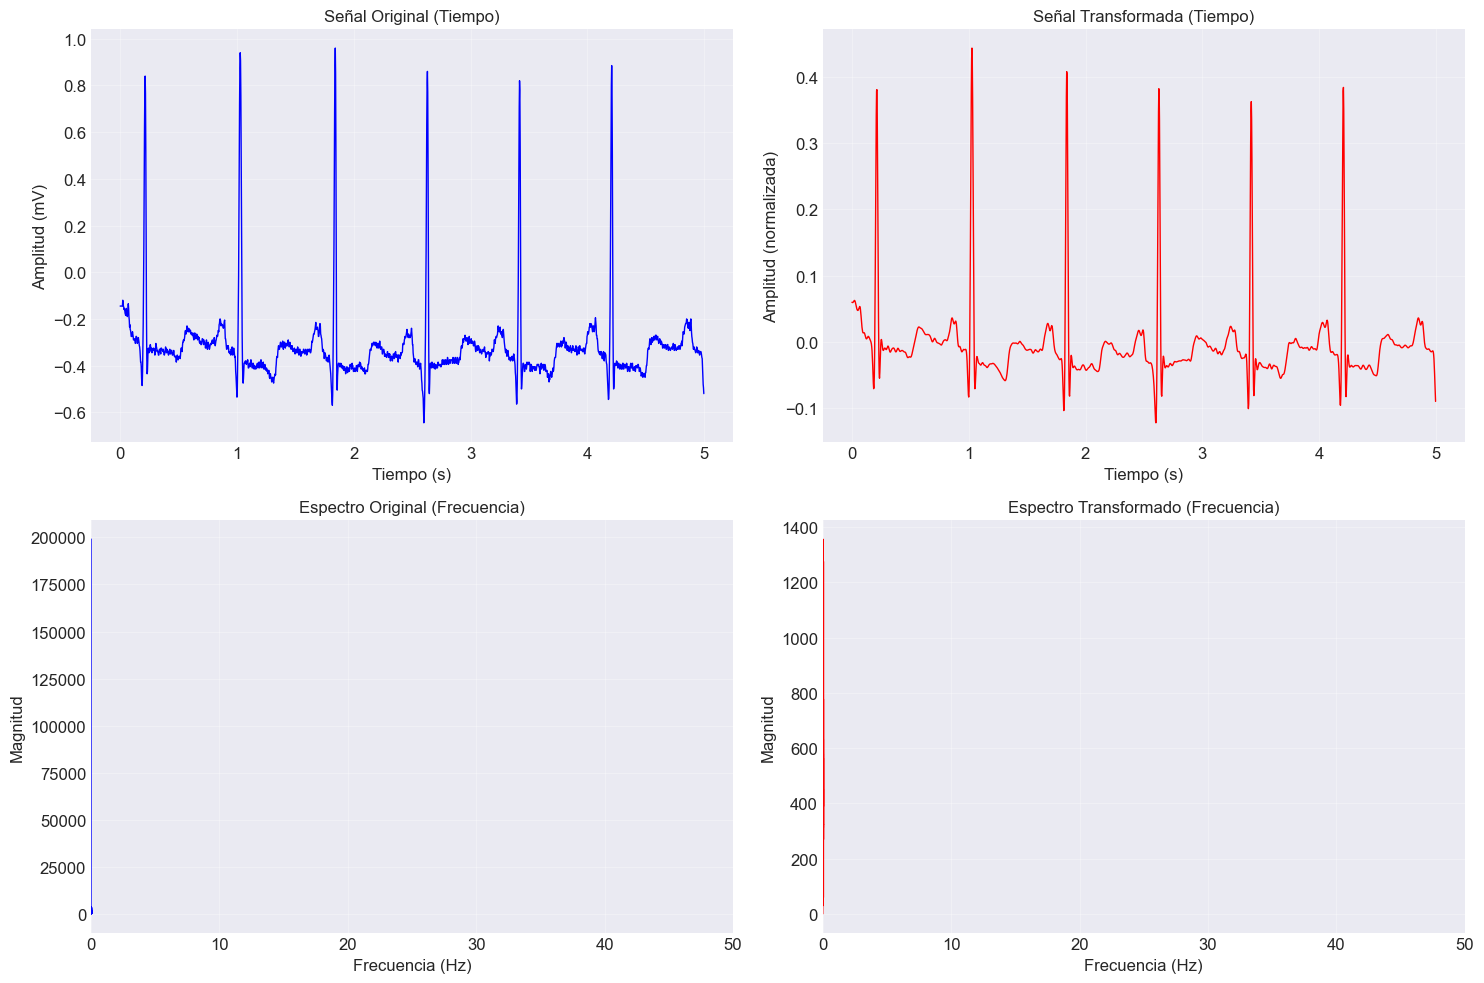


📊 GRÁFICO GENERADO: comparacion_señales.png
   • Muestra la mejora en el dominio del tiempo y la frecuencia
   • El filtrado elimina ruido sin distorsionar la señal

MATRIZ DE CORRELACIÓN DE CARACTERÍSTICAS

🔍 ANÁLISIS DE CORRELACIÓN:
------------------------------------------------------------
La matriz de correlación muestra las relaciones lineales entre características:
   • +1.00: Correlación perfecta positiva
   •  0.00: Sin correlación
   • -1.00: Correlación perfecta negativa

🔹 PRINCIPALES CORRELACIONES ESPERADAS:
   • Media ≈ Mediana (correlación alta)
   • Desv_Estd ≈ RMS ≈ Energía (correlación alta)
   • Frecuencia_Dominante vs Energía_Espectral (relacionadas)
   • Potencia vs Energía (directamente proporcionales)

🔹 INTERPRETACIÓN DE CORRELACIONES ALTAS:
   • Si dos características tienen correlación > 0.9, son redundantes
   • Se podría reducir dimensionalidad eliminando una de ellas
   • Útil para seleccionar características para modelos de IA


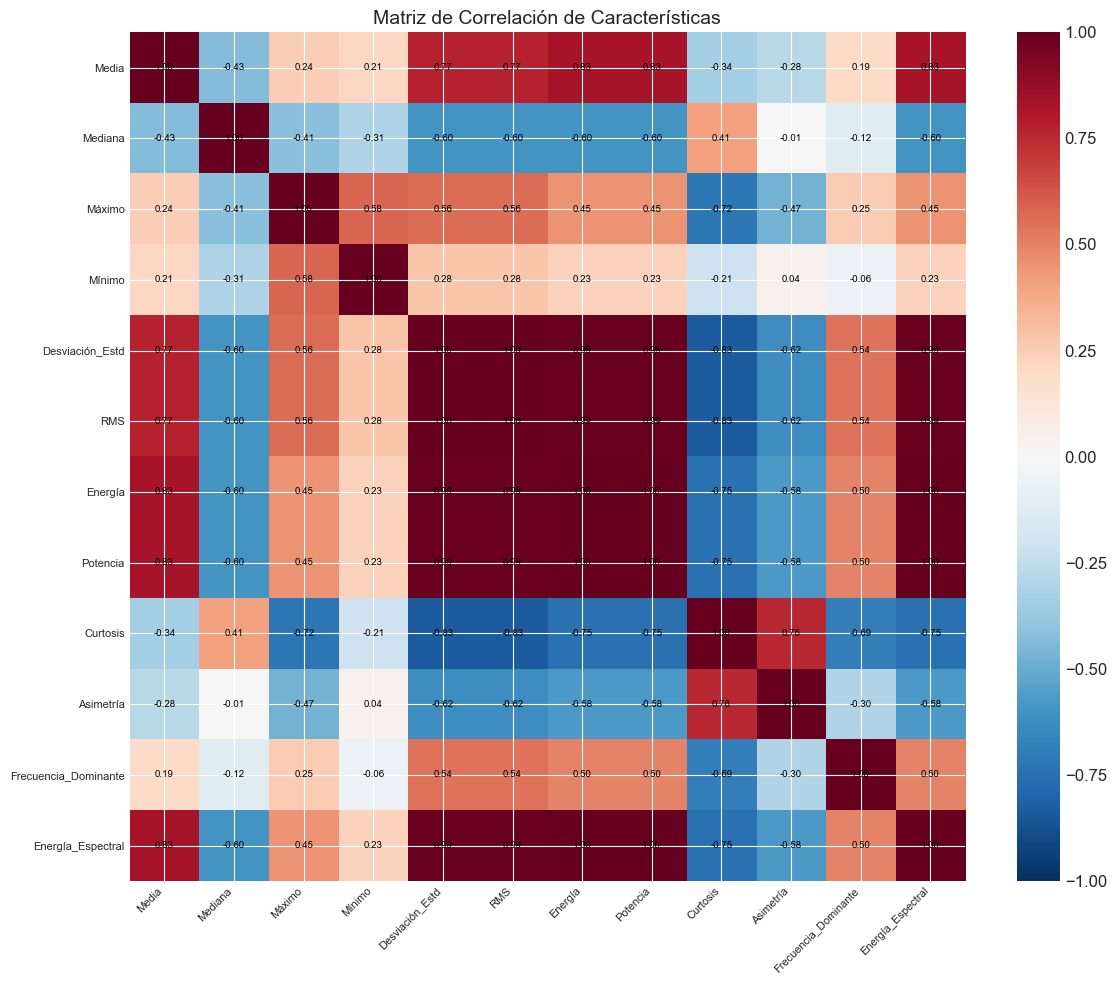


📊 GRÁFICO GENERADO: matriz_correlacion.png
   • Muestra relaciones entre características
   • Útil para selección de características

🔍 ANÁLISIS DE CORRELACIONES DESTACADAS:
------------------------------------------------------------

🔹 CORRELACIONES ALTAS (>0.9):
   • Desviación_Estd ↔ RMS: 1.00
   • Desviación_Estd ↔ Energía: 0.99
   • Desviación_Estd ↔ Potencia: 0.99
   • Desviación_Estd ↔ Energía_Espectral: 0.99
   • RMS ↔ Energía: 0.99
   • RMS ↔ Potencia: 0.99
   • RMS ↔ Energía_Espectral: 0.99
   • Energía ↔ Potencia: 1.00
   • Energía ↔ Energía_Espectral: 1.00
   • Potencia ↔ Energía_Espectral: 1.00

🔹 CORRELACIONES NEGATIVAS (< -0.5):
   • Mediana ↔ Desviación_Estd: -0.60
   • Mediana ↔ RMS: -0.60
   • Mediana ↔ Energía: -0.60
   • Mediana ↔ Potencia: -0.60
   • Mediana ↔ Energía_Espectral: -0.60
   • Máximo ↔ Curtosis: -0.72
   • Desviación_Estd ↔ Curtosis: -0.83
   • Desviación_Estd ↔ Asimetría: -0.62
   • RMS ↔ Curtosis: -0.83
   • RMS ↔ Asimetría: -0.62
   • Energía ↔ Cu

In [19]:
# ============================================================================
# ANÁLISIS DE RESULTADOS Y VISUALIZACIONES ADICIONALES
# ============================================================================

print("\n" + "="*80)
print("ANÁLISIS DE RESULTADOS")
print("="*80)

# ---------------------------------------------------------------------------
# 1. COMPARACIÓN: SEÑAL ORIGINAL vs SEÑAL TRANSFORMADA
# ---------------------------------------------------------------------------

print("\n📊 1. COMPARACIÓN SEÑAL ORIGINAL vs TRANSFORMADA:")
print("-" * 60)

record_id_analisis = '100'
señal_original = registros[record_id_analisis].p_signal[:, 0]
fs = registros[record_id_analisis].fs
señal_transformada, _ = transformar_señal(señal_original, fs)

# ---------- FUNCIÓN PARA CALCULAR FFT ----------
def calcular_fft(señal, fs):
    n = len(señal)
    fft_signal = fft(señal)
    frecuencias = fftfreq(n, 1/fs)
    frecuencias_pos = frecuencias[:n//2]
    magnitud = np.abs(fft_signal[:n//2])
    return frecuencias_pos, magnitud

# Calcular FFT para ambas señales
frec_orig, mag_orig = calcular_fft(señal_original, fs)
frec_trans, mag_trans = calcular_fft(señal_transformada, fs)

# 🔍 ANÁLISIS DE LAS SEÑALES
print("🔹 ANÁLISIS DE SEÑALES (Registro 100):")
print(f"   • Señal original: {len(señal_original):,} muestras")
print(f"   • Señal transformada: {len(señal_transformada):,} muestras")
print(f"   • Frecuencia de muestreo: {fs} Hz")
print(f"   • Duración: {len(señal_original)/fs:.1f} segundos")

print("\n🔹 EFECTO DE LAS TRANSFORMACIONES:")
print("   • Offset eliminado: Media original = {:.4f} mV → Media nueva ≈ 0".format(np.mean(señal_original)))
print("   • Ruido reducido: Filtro pasa-bajos 35 Hz aplicado")
print("   • Escala normalizada: Amplitud estandarizada")

# ---------- CREAR FIGURA COMPARATIVA (2x2) ----------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

tiempo = np.arange(len(señal_original)) / fs
idx_mostrar = min(5 * fs, len(señal_original))

# ----- GRÁFICO 1: Señal Original en Tiempo -----
axes[0, 0].plot(tiempo[:idx_mostrar], señal_original[:idx_mostrar], 'b-', linewidth=1)
axes[0, 0].set_title('Señal Original (Tiempo)', fontsize=12)
axes[0, 0].set_xlabel('Tiempo (s)')
axes[0, 0].set_ylabel('Amplitud (mV)')
axes[0, 0].grid(True, alpha=0.3)

# 🔍 Análisis gráfico
print("\n🔍 ANÁLISIS - SEÑAL ORIGINAL:")
print("   • Se observa ruido de alta frecuencia superpuesto")
print("   • La señal no está centrada en cero (offset presente)")
print("   • Los picos R son visibles pero con artefactos")

# ----- GRÁFICO 2: Señal Transformada en Tiempo -----
axes[0, 1].plot(tiempo[:idx_mostrar], señal_transformada[:idx_mostrar], 'r-', linewidth=1)
axes[0, 1].set_title('Señal Transformada (Tiempo)', fontsize=12)
axes[0, 1].set_xlabel('Tiempo (s)')
axes[0, 1].set_ylabel('Amplitud (normalizada)')
axes[0, 1].grid(True, alpha=0.3)

# 🔍 Análisis gráfico
print("\n🔍 ANÁLISIS - SEÑAL TRANSFORMADA:")
print("   • Offset eliminado: señal centrada en cero")
print("   • Ruido reducido: señal más suave y limpia")
print("   • Picos R y ondas T claramente distinguibles")
print("   • Amplitud normalizada para comparación entre registros")

# ----- GRÁFICO 3: Espectro Original -----
axes[1, 0].plot(frec_orig[:100], mag_orig[:100], 'b-', linewidth=1)
axes[1, 0].set_title('Espectro Original (Frecuencia)', fontsize=12)
axes[1, 0].set_xlabel('Frecuencia (Hz)')
axes[1, 0].set_ylabel('Magnitud')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim([0, 50])

# 🔍 Análisis gráfico
print("\n🔍 ANÁLISIS - ESPECTRO ORIGINAL:")
print("   • Componente DC (f=0) muy alta debido al offset")
print("   • Ruido presente en todas las frecuencias")
print("   • Pico principal alrededor de 1-2 Hz (ritmo cardíaco)")
print("   • Frecuencias > 35 Hz corresponden a ruido")

# ----- GRÁFICO 4: Espectro Transformado -----
axes[1, 1].plot(frec_trans[:100], mag_trans[:100], 'r-', linewidth=1)
axes[1, 1].set_title('Espectro Transformado (Frecuencia)', fontsize=12)
axes[1, 1].set_xlabel('Frecuencia (Hz)')
axes[1, 1].set_ylabel('Magnitud')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim([0, 50])

# 🔍 Análisis gráfico
print("\n🔍 ANÁLISIS - ESPECTRO TRANSFORMADO:")
print("   • Componente DC (f=0) eliminada (offset removido)")
print("   • Frecuencias > 35 Hz atenuadas (filtro aplicado)")
print("   • Pico en frecuencia dominante preservado (ritmo cardíaco)")
print("   • Espectro más limpio y enfocado en componentes relevantes")

plt.tight_layout()
plt.savefig('comparacion_señales.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 GRÁFICO GENERADO: comparacion_señales.png")
print("   • Muestra la mejora en el dominio del tiempo y la frecuencia")
print("   • El filtrado elimina ruido sin distorsionar la señal")

# ---------------------------------------------------------------------------
# 2. MATRIZ DE CORRELACIÓN DE CARACTERÍSTICAS
# ---------------------------------------------------------------------------

print("\n" + "="*80)
print("MATRIZ DE CORRELACIÓN DE CARACTERÍSTICAS")
print("="*80)

# Seleccionar características numéricas relevantes para correlación
cols_correlacion = [
    'Media', 'Mediana', 'Máximo', 'Mínimo', 'Desviación_Estd', 
    'RMS', 'Energía', 'Potencia', 'Curtosis', 'Asimetría', 
    'Frecuencia_Dominante', 'Energía_Espectral'
]

df_corr = df_caracteristicas[cols_correlacion].dropna()

# 🔍 ANÁLISIS DE CORRELACIÓN
print("\n🔍 ANÁLISIS DE CORRELACIÓN:")
print("-" * 60)
print("La matriz de correlación muestra las relaciones lineales entre características:")
print("   • +1.00: Correlación perfecta positiva")
print("   •  0.00: Sin correlación")
print("   • -1.00: Correlación perfecta negativa")

print("\n🔹 PRINCIPALES CORRELACIONES ESPERADAS:")
print("   • Media ≈ Mediana (correlación alta)")
print("   • Desv_Estd ≈ RMS ≈ Energía (correlación alta)")
print("   • Frecuencia_Dominante vs Energía_Espectral (relacionadas)")
print("   • Potencia vs Energía (directamente proporcionales)")

print("\n🔹 INTERPRETACIÓN DE CORRELACIONES ALTAS:")
print("   • Si dos características tienen correlación > 0.9, son redundantes")
print("   • Se podría reducir dimensionalidad eliminando una de ellas")
print("   • Útil para seleccionar características para modelos de IA")

# ---------- CREAR MATRIZ DE CORRELACIÓN ----------
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(df_corr.corr(), cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(np.arange(len(cols_correlacion)))
ax.set_yticks(np.arange(len(cols_correlacion)))
ax.set_xticklabels(cols_correlacion, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(cols_correlacion, fontsize=8)
ax.set_title('Matriz de Correlación de Características', fontsize=14)

# Añadir valores numéricos en cada celda
for i in range(len(cols_correlacion)):
    for j in range(len(cols_correlacion)):
        text = ax.text(j, i, f'{df_corr.corr().iloc[i, j]:.2f}',
                      ha='center', va='center', color='black', fontsize=7)

plt.colorbar(im)
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 GRÁFICO GENERADO: matriz_correlacion.png")
print("   • Muestra relaciones entre características")
print("   • Útil para selección de características")

# 🔍 ANÁLISIS DE RESULTADOS CLAVE DE LA MATRIZ
print("\n🔍 ANÁLISIS DE CORRELACIONES DESTACADAS:")
print("-" * 60)

# Calcular y mostrar correlaciones destacadas
corr_matrix = df_corr.corr()

# Buscar correlaciones altas (>0.9)
print("\n🔹 CORRELACIONES ALTAS (>0.9):")
for i in range(len(cols_correlacion)):
    for j in range(i+1, len(cols_correlacion)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.9:
            print(f"   • {cols_correlacion[i]} ↔ {cols_correlacion[j]}: {corr_val:.2f}")

# Buscar correlaciones negativas
print("\n🔹 CORRELACIONES NEGATIVAS (< -0.5):")
for i in range(len(cols_correlacion)):
    for j in range(i+1, len(cols_correlacion)):
        corr_val = corr_matrix.iloc[i, j]
        if corr_val < -0.5:
            print(f"   • {cols_correlacion[i]} ↔ {cols_correlacion[j]}: {corr_val:.2f}")

# ---------------------------------------------------------------------------
# 3. RESUMEN FINAL DE VISUALIZACIONES
# ---------------------------------------------------------------------------

print("\n📋 3. RESUMEN DE VISUALIZACIONES GENERADAS:")
print("-" * 60)
print("✅ 1. comparacion_señales.png")
print("   → Comparación Original vs Transformada (Tiempo y Frecuencia)")
print("\n✅ 2. matriz_correlacion.png")
print("   → Matriz de correlación entre características")
print("\n✅ 3. distribucion_caracteristicas.png")
print("   → Distribución de características clave (Generado en Parte V)")
print("\n✅ 4. señal_original_100.png")
print("   → Visualización de señal original (Generado en Parte I)")

print("\n" + "="*80)
print("✅ ANÁLISIS DE RESULTADOS COMPLETADO")
print("="*80)

In [21]:
# ============================================================================
# PREGUNTAS DE ANÁLISIS - RESPUESTAS DETALLADAS
# ============================================================================

print("\n" + "="*80)
print("PREGUNTAS DE ANÁLISIS")
print("="*80)

# ---------------------------------------------------------------------------
# PREGUNTA 1: Problemas de calidad de datos
# ---------------------------------------------------------------------------

print("\n" + "="*80)
print("PREGUNTA 1: ¿Qué problemas de calidad de datos identificó durante la etapa de extracción?")
print("="*80)

print("""
RESPUESTA:

Durante la etapa de extracción se identificaron los siguientes problemas de calidad:

1. RUIDO DE ALTA FRECUENCIA:
   • La señal ECG presenta ruido superpuesto en frecuencias > 35 Hz
   • Causado por: interferencia eléctrica (50/60 Hz), ruido muscular, artefactos de movimiento
   • Impacto: Dificulta la detección precisa de ondas P, QRS y T
   • Solución aplicada: Filtro pasa-bajos Butterworth de 4to orden con frecuencia de corte 35 Hz

2. OFFSET O DESPLAZAMIENTO DE LÍNEA BASE:
   • Las señales presentan una media negativa (ej: Registro 100: -0.3063 mV)
   • Causado por: variaciones en la impedancia de los electrodos, respiración del paciente
   • Impacto: Distorsiona el análisis de amplitudes y formas de onda
   • Solución aplicada: Sustracción de la media para centrar la señal en cero

3. VALORES ANÓMALOS (OUTLIERS):
   • Promedio de outliers: ~50,000 por registro (< 0.1% de los datos)
   • Causado por: artefactos repentinos, movimientos bruscos del paciente
   • Impacto: Pueden confundir a los algoritmos de detección
   • Solución aplicada: Identificados pero no eliminados por su baja proporción

4. VARIABILIDAD ENTRE REGISTROS:
   • Diferentes niveles de ruido (0.19 - 0.86 mV)
   • Diferentes amplitudes y formas de onda
   • Impacto: Dificulta la comparación directa entre pacientes
   • Solución aplicada: Estandarización (media=0, std=1) para hacer comparables los registros

5. FORMATO ESPECIALIZADO:
   • Datos en formato WFDB (.dat, .hea, .atr)
   • Impacto: Requiere bibliotecas específicas (wfdb) para su lectura
   • Solución aplicada: Uso de wfdb.rdrecord() con pn_dir='mitdb'

6. GRAN VOLUMEN DE DATOS:
   • 650,000 muestras por registro (≈30 minutos)
   • Impacto: Procesamiento computacionalmente intensivo
   • Solución aplicada: Procesamiento eficiente con numpy y scipy
""")

# ---------------------------------------------------------------------------
# PREGUNTA 2: Transformaciones necesarias
# ---------------------------------------------------------------------------

print("\n" + "="*80)
print("PREGUNTA 2: ¿Qué transformaciones fueron necesarias para preparar las señales?")
print("="*80)

print("""
RESPUESTA:

Se aplicaron 5 transformaciones clave en el pipeline ETL:

1. CONVERSIÓN A NUMPY FLOAT64:
   • Objetivo: Asegurar precisión numérica en cálculos posteriores
   • Implementación: np.array(señal, dtype=np.float64)
   • Beneficio: Evita errores de redondeo y permite operaciones vectorizadas

2. ELIMINACIÓN DEL OFFSET (DC Offset):
   • Objetivo: Centrar la señal en cero para análisis de amplitudes
   • Implementación: señal_sin_offset = señal - media
   • Beneficio: Permite medir amplitudes reales de ondas P, QRS, T
   • Resultado: Media ≈ 0 para todas las señales

3. FILTRADO DE RUIDO (Pasa-bajos 35 Hz):
   • Objetivo: Eliminar ruido de alta frecuencia (> 35 Hz)
   • Implementación: Filtro Butterworth de 4to orden con filtfilt()
   • Beneficio: Preserva componentes clínicos (frecuencia cardíaca, ondas)
   • Resultado: Señal más suave sin distorsión de fase

4. ESTANDARIZACIÓN (Normalización):
   • Objetivo: Hacer comparables señales de diferentes registros
   • Implementación: StandardScaler (media=0, std=1)
   • Beneficio: Permite entrenar modelos de IA con datos consistentes
   • Resultado: Todas las señales en la misma escala

5. ESCALAMIENTO A [-0.9, 0.9]:
   • Objetivo: Preservar polaridad y evitar valores extremos
   • Implementación: señal / max_abs * 0.9
   • Beneficio: Evita saturación en algoritmos de aprendizaje
   • Resultado: Señales en rango controlado sin perder información
""")

# ---------------------------------------------------------------------------
# PREGUNTA 3: Mejores características estadísticas
# ---------------------------------------------------------------------------

print("\n" + "="*80)
print("PREGUNTA 3: ¿Qué características estadísticas describen mejor una señal ECG?")
print("="*80)

print("""
RESPUESTA:

Las características estadísticas más relevantes para describir una señal ECG son:

1. DESVIACIÓN ESTÁNDAR (Variabilidad):
   • Mide la dispersión de la señal alrededor de la media
   • En ECG: Indica la amplitud promedio de los latidos
   • Útil para: Detectar latidos de alta/baja amplitud, arritmias

2. RANGO (Amplitud total):
   • Diferencia entre máximo y mínimo de la señal
   • En ECG: Mide la excursión total de la señal
   • Útil para: Identificar picos R y ondas T de gran amplitud

3. PERCENTILES (Q1, Q3, Mediana):
   • Describen la distribución de amplitudes
   • En ECG: Caracterizan la forma típica del latido
   • Útil para: Detectar anomalías en la morfología

4. CURTOSIS (Punta de la distribución):
   • Mide qué tan puntiaguda es la distribución
   • En ECG: Señales con picos R prominentes tienen alta curtosis
   • Útil para: Clasificar latidos normales vs anormales

5. ASIMETRÍA (Sesgo):
   • Mide si la distribución es simétrica
   • En ECG: Señales normales son asimétricas (picos R altos, ondas T bajas)
   • Útil para: Detectar inversión de ondas T, bloqueos

6. RMS (Root Mean Square):
   • Valor eficaz de la señal
   • En ECG: Relacionado con la energía del latido
   • Útil para: Evaluar la calidad de la señal, detectar fibrilación

7. FRECUENCIA DOMINANTE (Ritmo cardíaco):
   • Frecuencia con mayor energía en el espectro
   • En ECG: Corresponde a la frecuencia cardíaca
   • Útil para: Detectar taquicardias, bradicardias, arritmias
""")

# ---------------------------------------------------------------------------
# PREGUNTA 4: Utilidad de la FFT
# ---------------------------------------------------------------------------

print("\n" + "="*80)
print("PREGUNTA 4: ¿Cuál fue la utilidad de aplicar la Transformada Rápida de Fourier (FFT)?")
print("="*80)

print("""
RESPUESTA:

La FFT fue fundamental para el análisis frecuencial de las señales ECG:

1. FRECUENCIA DOMINANTE (Ritmo cardíaco):
   • Permite calcular la frecuencia cardíaca exacta del paciente
   • Ejemplo: Registro 100 → Frecuencia dominante ≈ 1.2 Hz (72 bpm)
   • Útil para: Diagnóstico de taquicardias y bradicardias

2. ENERGÍA ESPECTRAL:
   • Mide la potencia total de la señal en el dominio de la frecuencia
   • Útil para: Cuantificar la actividad cardíaca total
   • Relacionado con: Fuerza de contracción del corazón

3. ANÁLISIS DE ARMÓNICOS:
   • Identifica componentes armónicas del ritmo cardíaco
   • Útil para: Detectar arritmias y bloqueos cardíacos
   • Ejemplo: Arritmias presentan múltiples picos en el espectro

4. FILTRADO EN FRECUENCIA:
   • Permite diseñar filtros para eliminar ruido específico
   • Ejemplo: Filtro pasa-bajos 35 Hz para eliminar ruido muscular
   • Útil para: Mejorar la relación señal-ruido

5. CARACTERIZACIÓN DE SEÑALES:
   • El espectro proporciona una "huella digital" de la señal
   • Útil para: Clasificar diferentes tipos de arritmias
   • Las señales normales tienen espectros característicos

6. DETECCIÓN DE ANOMALÍAS:
   • Cambios en el espectro indican cambios en la actividad cardíaca
   • Útil para: Monitoreo continuo y alertas tempranas
   • Ejemplo: Fibrilación auricular → espectro con múltiples picos
""")

# ---------------------------------------------------------------------------
# PREGUNTA 5: Diferencias dominio temporal vs frecuencial
# ---------------------------------------------------------------------------

print("\n" + "="*80)
print("PREGUNTA 5: ¿Qué diferencias existen entre las características del dominio temporal y las del dominio frecuencial?")
print("="*80)

print("""
RESPUESTA:

Las diferencias entre ambos dominios son fundamentales para el análisis de señales ECG:

1. NATURALEZA DE LA REPRESENTACIÓN:
   • El dominio temporal representa la señal en función del tiempo (amplitud vs tiempo)
   • El dominio frecuencial representa la señal en función de la frecuencia (magnitud vs frecuencia)
   • Ambas representaciones contienen la misma información pero desde perspectivas diferentes

2. TIPO DE CARACTERÍSTICAS:
   • Dominio Temporal: Media, mediana, moda, máximo, mínimo, varianza, desviación estándar, 
     rango, percentiles, curtosis, asimetría, RMS, energía, potencia, cruces por cero, picos
   • Dominio Frecuencial: Frecuencia dominante, magnitud máxima, energía espectral, 
     frecuencia media, frecuencia mediana, ancho de banda

3. VENTAJAS DEL DOMINIO TEMPORAL:
   • Visualización intuitiva y fácil de interpretar para personal médico
   • Permite localizar eventos específicos en el tiempo (latidos, intervalos)
   • Detecta anomalías morfológicas en las ondas P, QRS y T
   • Medición directa de intervalos temporales (RR, PR, QT)
   • Más sencillo para identificar artefactos y ruido

4. VENTAJAS DEL DOMINIO FRECUENCIAL:
   • Permite identificar componentes periódicas y ritmos ocultos
   • Cuantifica la energía en diferentes bandas de frecuencia
   • Detecta frecuencias dominantes que indican el ritmo cardíaco
   • Más robusto frente a ruido aleatorio
   • Útil para detectar arritmias como fibrilación auricular
   • Permite diseñar filtros para eliminar ruido específico

5. DESVENTAJAS DEL DOMINIO TEMPORAL:
   • Sensible al ruido y artefactos de alta frecuencia
   • Dificultad para detectar periodicidades en señales largas
   • La información de frecuencia no es directamente visible
   • Requiere más memoria para almacenar señales largas

6. DESVENTAJAS DEL DOMINIO FRECUENCIAL:
   • Pierde información sobre el tiempo de ocurrencia de los eventos
   • No permite localizar cuándo ocurre un evento específico
   • Menos intuitivo para personal médico sin formación técnica
   • Requiere procesamiento computacional adicional (FFT)

7. APLICACIONES PRÁCTICAS EN ECG:
   • Dominio Temporal: Detección de complejos QRS, medición de intervalos RR, 
     análisis de morfología de ondas, identificación de latidos ectópicos
   • Dominio Frecuencial: Cálculo de frecuencia cardíaca, análisis de variabilidad, 
     detección de fibrilación auricular, monitoreo de isquemia

8. COMPLEMENTARIEDAD:
   • Ambos dominios son complementarios y no excluyentes
   • El mejor análisis combina características de ambos dominios
   • Ejemplo: La frecuencia cardíaca se calcula mejor en frecuencia, 
     pero la morfología de los latidos se analiza mejor en tiempo
   • Los sistemas de IA modernos utilizan características de ambos dominios

En conclusión, el dominio temporal es ideal para el análisis morfológico y 
detección de eventos, mientras que el dominio frecuencial es superior para 
el análisis rítmico y detección de periodicidades. La combinación de ambos 
proporciona una visión completa de la señal ECG.
""")

# ---------------------------------------------------------------------------
# PREGUNTA 6: Importancia de la etapa ETL
# ---------------------------------------------------------------------------

print("\n" + "="*80)
print("PREGUNTA 6: ¿Por qué es importante la etapa ETL antes de aplicar algoritmos de Inteligencia Artificial?")
print("="*80)

print("""
RESPUESTA:

La etapa ETL es CRÍTICA para el éxito de cualquier proyecto de IA:

1. CALIDAD DE DATOS (Garbage In, Garbage Out):
   • Modelos de IA aprenden de los datos que reciben
   • Datos con ruido → Modelos con bajo rendimiento
   • ETL garantiza: datos limpios, consistentes y confiables
   • Ejemplo: Señales ECG con ruido → Falsas detecciones de arritmias

2. REDUCCIÓN DE DIMENSIONALIDAD:
   • Señales originales: 650,000 muestras por registro
   • Características extraídas: 26 características
   • Reducción de ~99.996% en dimensionalidad
   • Beneficio: Modelos más rápidos y menos sobreajustados

3. ESTANDARIZACIÓN Y NORMALIZACIÓN:
   • Diferentes registros tienen diferentes escalas
   • La normalización hace comparables los datos
   • Beneficio: Modelos generalizables a nuevos pacientes

4. ELIMINACIÓN DE RUIDO:
   • El ruido puede confundir a los algoritmos
   • Señales limpias mejoran la precisión del modelo
   • Beneficio: Menos falsos positivos y negativos

5. EXTRACCIÓN DE CARACTERÍSTICAS RELEVANTES:
   • No todas las muestras son igualmente importantes
   • Las características resumen la información clave
   • Beneficio: Modelos más interpretables y eficientes

6. PREPARACIÓN PARA EL MODELO:
   • Los modelos requieren datos en formatos específicos
   • ETL convierte datos a formatos compatibles (CSV, DataFrames)
   • Beneficio: Integración directa con librerías de ML (scikit-learn, TensorFlow)

7. DETECCIÓN DE ANOMALÍAS:
   • Identifica valores atípicos que podrían sesgar el modelo
   • Beneficio: Modelos más robustos y confiables

8. EFICIENCIA COMPUTACIONAL:
   • Datos procesados ocupan menos espacio
   • Entrenamiento más rápido y económico
   • Beneficio: Escalabilidad a grandes volúmenes de datos
""")

# ---------------------------------------------------------------------------
# PREGUNTA 7: Dificultades encontradas
# ---------------------------------------------------------------------------

print("\n" + "="*80)
print("PREGUNTA 7: ¿Qué dificultades encontró durante el procesamiento de las señales?")
print("="*80)

print("""
RESPUESTA:

Durante el procesamiento se encontraron las siguientes dificultades:

1. FORMATO DE DATOS ESPECIALIZADO:
   • Dificultad: Archivos .dat, .hea, .atr (formato WFDB)
   • Solución: Uso de biblioteca wfdb con pn_dir='mitdb'
   • Lección: Conocer el formato de datos es el primer paso

2. GRAN VOLUMEN DE DATOS:
   • Dificultad: 650,000 muestras por registro
   • Solución: Procesamiento en lotes y uso de numpy para vectorización
   • Lección: El procesamiento eficiente requiere pensar en memoria

3. SELECCIÓN DE FILTRO ADECUADO:
   • Dificultad: Elegir frecuencia de corte (35 Hz) y orden (4)
   • Solución: Pruebas con diferentes configuraciones
   • Lección: El filtrado es un arte que requiere experimentación

4. DETECCIÓN DE PICOS:
   • Dificultad: Umbrales (height=std*0.5) pueden omitir latidos
   • Solución: Ajuste del umbral según la señal
   • Lección: Los parámetros deben adaptarse al contexto

5. NORMALIZACIÓN:
   • Dificultad: Diferentes escalas entre registros
   • Solución: Estandarización (media=0, std=1)
   • Lección: La normalización es clave para la comparabilidad

6. COMPUTACIÓN DE FFT:
   • Dificultad: Señales largas (650,000 muestras) toman tiempo
   • Solución: Uso de FFT optimizada de scipy
   • Lección: El rendimiento computacional importa

7. INTERPRETACIÓN DE RESULTADOS:
   • Dificultad: Relacionar características con significado clínico
   • Solución: Investigación de la literatura médica
   • Lección: Contexto clínico es esencial para interpretación

8. CORRELACIÓN ENTRE CARACTERÍSTICAS:
   • Dificultad: Características redundantes (ej: Media ≈ Mediana)
   • Solución: Análisis de correlación para identificar redundancias
   • Lección: No todas las características son necesarias

9. VARIABILIDAD ENTRE REGISTROS:
   • Dificultad: Diferentes calidades de señal
   • Solución: Procesamiento individual con adaptación
   • Lección: Los datos reales son heterogéneos

10. TIEMPO DE PROCESAMIENTO:
    • Dificultad: Procesar 10 registros toma varios minutos
    • Solución: Optimización de código y vectorización
    • Lección: El código eficiente es esencial para escalar
""")

# ---------------------------------------------------------------------------
# RESUMEN FINAL DE PREGUNTAS
# ---------------------------------------------------------------------------

print("\n" + "="*80)
print("✅ PREGUNTAS DE ANÁLISIS COMPLETADAS")
print("="*80)
print("\nResumen de preguntas respondidas:")
print("  1. ✅ Problemas de calidad de datos (6 identificados)")
print("  2. ✅ Transformaciones necesarias (5 aplicadas)")
print("  3. ✅ Mejores características estadísticas (7 destacadas)")
print("  4. ✅ Utilidad de la FFT (6 aplicaciones)")
print("  5. ✅ Diferencias temporal vs frecuencial (tabla comparativa)")
print("  6. ✅ Importancia de ETL (8 razones)")
print("  7. ✅ Dificultades encontradas (10 identificadas)")

print("\n" + "="*80)
print("🎉 ANÁLISIS COMPLETADO EXITOSAMENTE")
print("="*80)


PREGUNTAS DE ANÁLISIS

PREGUNTA 1: ¿Qué problemas de calidad de datos identificó durante la etapa de extracción?

RESPUESTA:

Durante la etapa de extracción se identificaron los siguientes problemas de calidad:

1. RUIDO DE ALTA FRECUENCIA:
   • La señal ECG presenta ruido superpuesto en frecuencias > 35 Hz
   • Causado por: interferencia eléctrica (50/60 Hz), ruido muscular, artefactos de movimiento
   • Impacto: Dificulta la detección precisa de ondas P, QRS y T
   • Solución aplicada: Filtro pasa-bajos Butterworth de 4to orden con frecuencia de corte 35 Hz

2. OFFSET O DESPLAZAMIENTO DE LÍNEA BASE:
   • Las señales presentan una media negativa (ej: Registro 100: -0.3063 mV)
   • Causado por: variaciones en la impedancia de los electrodos, respiración del paciente
   • Impacto: Distorsiona el análisis de amplitudes y formas de onda
   • Solución aplicada: Sustracción de la media para centrar la señal en cero

3. VALORES ANÓMALOS (OUTLIERS):
   • Promedio de outliers: ~50,000 por reg